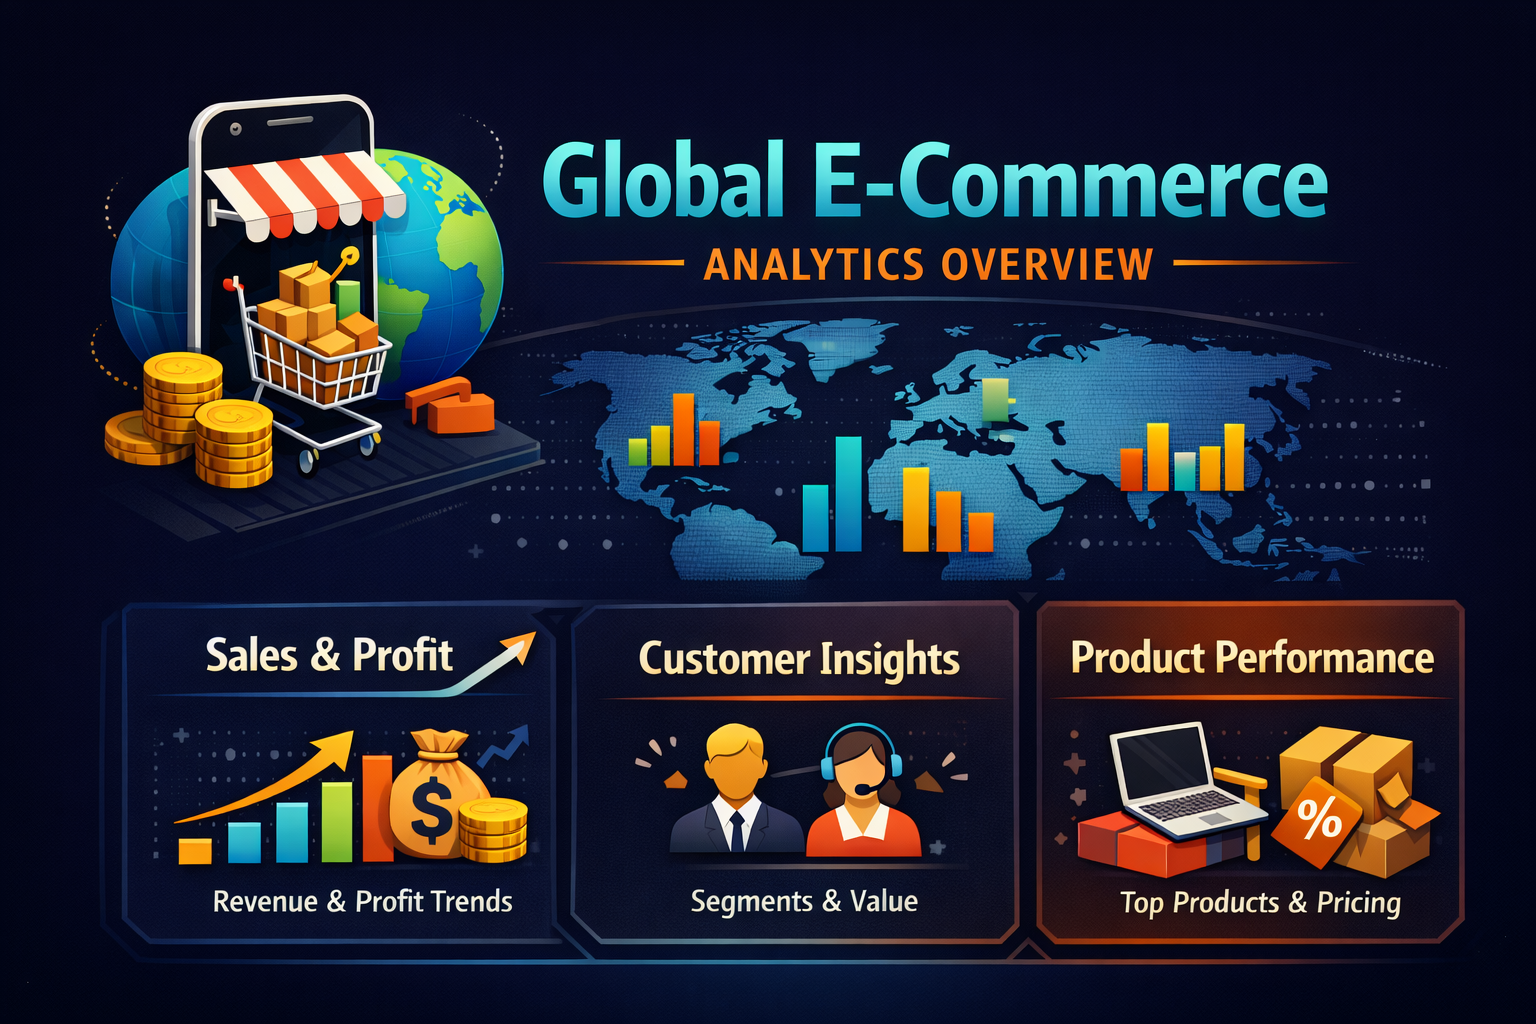

In [1]:
from IPython.display import Image, display
display(Image(filename='/kaggle/input/datasets/mhassansaboor/global-ecommerce/global_ecommerce.png'))

# **🌐 Global E-Commerce Sales & Customer Analysis**

## **📖 Introduction**

In today’s data-driven retail landscape, understanding customer behavior, product performance, and financial metrics is essential for business growth. This notebook provides a **comprehensive exploratory data analysis (EDA)** of a **synthetic global e-commerce dataset**, simulating **2,000 transactions across 20 countries over a 3-year period (2023–2025)**. 

The goal of this analysis is to extract actionable insights that can inform **strategic business decisions**, **optimize profitability**, and improve **customer segmentation and targeting**.

---

## **📊 Dataset Overview**

The dataset consists of **15 features** covering **orders, customers, products, sales, discounts, shipping, and profit**:

- **Order_ID**: Unique transaction identifier  
- **Order_Date**: Date of transaction  
- **Customer_Name**: Customer full name  
- **Customer_Segment**: Consumer, Corporate, or Home Office  
- **Country**: Customer country (20 countries)  
- **Region**: Geographic region (North America, Europe, Asia Pacific, Middle East & Africa, South America)  
- **Product_Category**: Technology, Furniture, Office Supplies, Clothing & Accessories  
- **Product_Name**: Specific product (40 unique products)  
- **Quantity**: Units purchased  
- **Unit_Price**: Price per unit in USD  
- **Discount_Percent**: Discount applied (%)  
- **Total_Sales**: Revenue per order after discount  
- **Shipping_Cost**: Shipping fee  
- **Profit**: Net profit per order  
- **Payment_Method**: Credit Card, PayPal, Bank Transfer, or Cash on Delivery  

**Key characteristics**:

- Weighted distributions for customer segments, regions, and product categories  
- Seasonal ordering patterns (Q4 peak)  
- Region-specific shipping costs  
- Category-specific profit margins  
- Corporate customers receive higher discounts  

---

## **🎯 Objectives**

This analysis aims to answer critical business questions, including:

1. How do **sales and profit trends vary** across regions, countries, and product categories?  
2. Which **customer segments** generate the highest value and profitability?  
3. How do **discounts and shipping costs** influence profitability?  
4. What are the **temporal patterns** in order volumes, including seasonality and weekday/weekend trends?  
5. Are revenue and profit concentrated in a small subset of **products or regions** (Pareto principle)?  
6. How do product categories perform in terms of **sales, profit, and basket size**?  
7. Which **payment methods** are preferred across different markets?  

---

## **💡 Expected Insights**

From this EDA, we expect to uncover insights such as:

- High sales regions may not always correspond to **high profit margins** due to shipping costs and discounts.  
- Corporate customers, while receiving higher discounts, often generate **larger average order values**.  
- Seasonal peaks, particularly in **Q4**, drive significant revenue growth.  
- Some products may rely heavily on discounts to drive sales, **reducing overall profitability**.  
- A small fraction of products or countries may contribute disproportionately to total revenue (**Pareto principle**).  
- Shipping costs relative to sales vary by category and region, highlighting potential **operational inefficiencies**.  

---

## **📌 Notebook Structure**

This notebook is organized into **17 analytical sections**, each with visually appealing **dark-themed plots**:

1. **Business Performance Overview**  
2. **Geographic Insights**  
3. **Customer Behavior Insights**  
4. **Product Performance Insights**  
5. **Discount Strategy Analysis**  
6. **Time-Based Insights**  
7. **Payment Method Analysis**  
8. **Shipping Cost Impact**  
9. **Order Value Insights**  
10. **Advanced Analytical Insights**  
11. **Revenue Concentration Analysis (Pareto Principle)**  
12. **Profit Margin Distribution**  
13. **Discount Elasticity Analysis**  
14. **Shipping Cost Efficiency**  
15. **Profitability Efficiency Matrix**  
16. **Customer Value Analysis**  
17. **Temporal Feature Engineering**  

Each section contains **interactive visualizations, dashboards, and key insights** to provide a holistic understanding of the business.

---

**Let’s dive into the analysis and uncover actionable insights to optimize global e-commerce performance!**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
# Dark theme
plt.style.use("dark_background")

bright_colors = [
    "#00E5FF","#FF6B6B","#FFD93D","#6BCB77",
    "#4D96FF","#FF9F1C","#C77DFF","#F72585",
    "#2EC4B6","#FFBE0B"
]

In [3]:
df = pd.read_csv("/kaggle/input/datasets/muhammadaammartufail/global-e-commerce-sales-and-customer-data/global_ecommerce_sales.csv")

In [4]:
df.sample(10)

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
1574,ORD-10163,2025-05-24,Priya Brown,Corporate,China,Asia Pacific,Office Supplies,Premium Notebook Set A5,9,24.53,15,187.65,27.64,60.66,Credit Card
1070,ORD-10563,2024-08-28,Karen Rossi,Consumer,South Korea,Asia Pacific,Furniture,Floating Wall Shelves Set,4,91.15,5,346.37,13.75,113.86,Bank Transfer
1831,ORD-11975,2025-10-09,Kenji Moreau,Consumer,Canada,North America,Technology,Laptop Stand Adjustable,6,35.76,5,203.83,16.97,68.85,Bank Transfer
1826,ORD-11081,2025-10-07,Amir Williams,Consumer,Mexico,North America,Technology,Wireless Ergonomic Mouse,9,60.42,0,543.78,12.46,232.24,Credit Card
140,ORD-11007,2023-03-26,Olga Russo,Consumer,Australia,Asia Pacific,Furniture,Filing Cabinet 3-Drawer,4,210.65,0,842.60,11.11,325.93,Credit Card
1640,ORD-11425,2025-06-25,Li Harris,Consumer,Mexico,North America,Technology,Tablet Stand Holder,3,22.60,10,61.02,6.51,17.22,Credit Card
909,ORD-11160,2024-05-25,Clara Romano,Consumer,India,Asia Pacific,Office Supplies,Ballpoint Pen Pack 12,2,14.19,10,25.54,10.01,2.76,Credit Card
42,ORD-10017,2023-01-31,Kenji Nilsson,Home Office,Japan,Asia Pacific,Clothing & Accessories,Silk Tie Collection,3,18.32,0,54.96,12.91,14.57,Credit Card
443,ORD-10500,2023-09-09,Sakura Ali,Consumer,Nigeria,Middle East & Africa,Technology,Smart LED Desk Lamp,2,61.26,10,110.27,14.33,28.55,Credit Card
5,ORD-11746,2023-01-05,Fatima Suzuki,Consumer,Mexico,North America,Furniture,Bookshelf 5-Tier,1,61.93,10,55.74,5.88,12.70,PayPal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


# **1️⃣ Business Performance Overview**

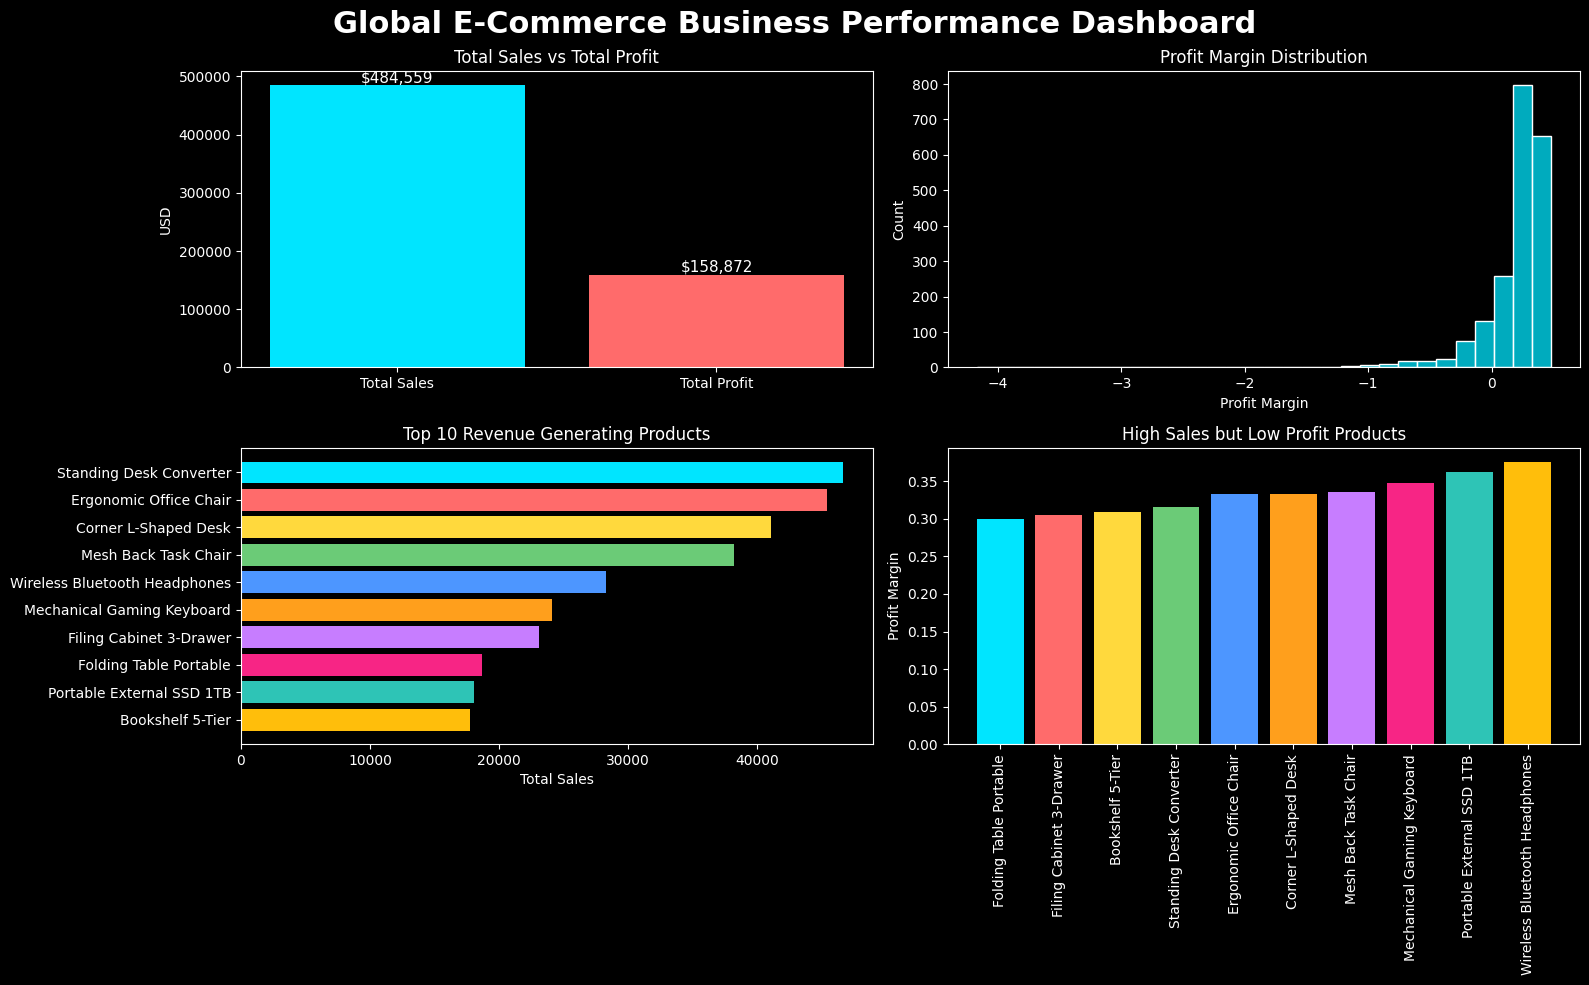

In [6]:
# ----- Feature Engineering -----
df["Profit_Margin"] = df["Profit"] / df["Total_Sales"]

# Top revenue products
top_products = (
    df.groupby("Product_Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# High sales low profit
product_sales_profit = df.groupby("Product_Name").agg({
    "Total_Sales":"sum",
    "Profit":"sum"
})

product_sales_profit["Profit_Margin"] = (
    product_sales_profit["Profit"] /
    product_sales_profit["Total_Sales"]
)

high_sales_low_profit = (
    product_sales_profit
    .sort_values("Total_Sales", ascending=False)
    .head(10)
    .sort_values("Profit_Margin")
)

# KPI values
total_sales = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()

# ----- Dashboard Layout -----
fig, axes = plt.subplots(2,2, figsize=(16,10))

fig.suptitle(
    "Global E-Commerce Business Performance Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ---- 1 Total Sales vs Profit ----
ax = axes[0,0]

bars = ax.bar(
    ["Total Sales","Total Profit"],
    [total_sales,total_profit],
    color=bright_colors[:2]
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Total Sales vs Total Profit")
ax.set_ylabel("USD")

# ---- 2 Profit Margin Distribution ----
ax = axes[0,1]

sns.histplot(
    df["Profit_Margin"],
    bins=30,
    color="#00E5FF",
    ax=ax
)

ax.set_title("Profit Margin Distribution")
ax.set_xlabel("Profit Margin")

# ---- 3 Top Revenue Products ----
ax = axes[1,0]

ax.barh(
    top_products.index,
    top_products.values,
    color=bright_colors
)

ax.set_title("Top 10 Revenue Generating Products")
ax.set_xlabel("Total Sales")
ax.invert_yaxis()

# ---- 4 High Sales but Low Profit ----
ax = axes[1,1]

ax.bar(
    high_sales_low_profit.index,
    high_sales_low_profit["Profit_Margin"],
    color=bright_colors
)

ax.set_title("High Sales but Low Profit Products")
ax.set_ylabel("Profit Margin")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# **2️⃣ Geographic Insights**

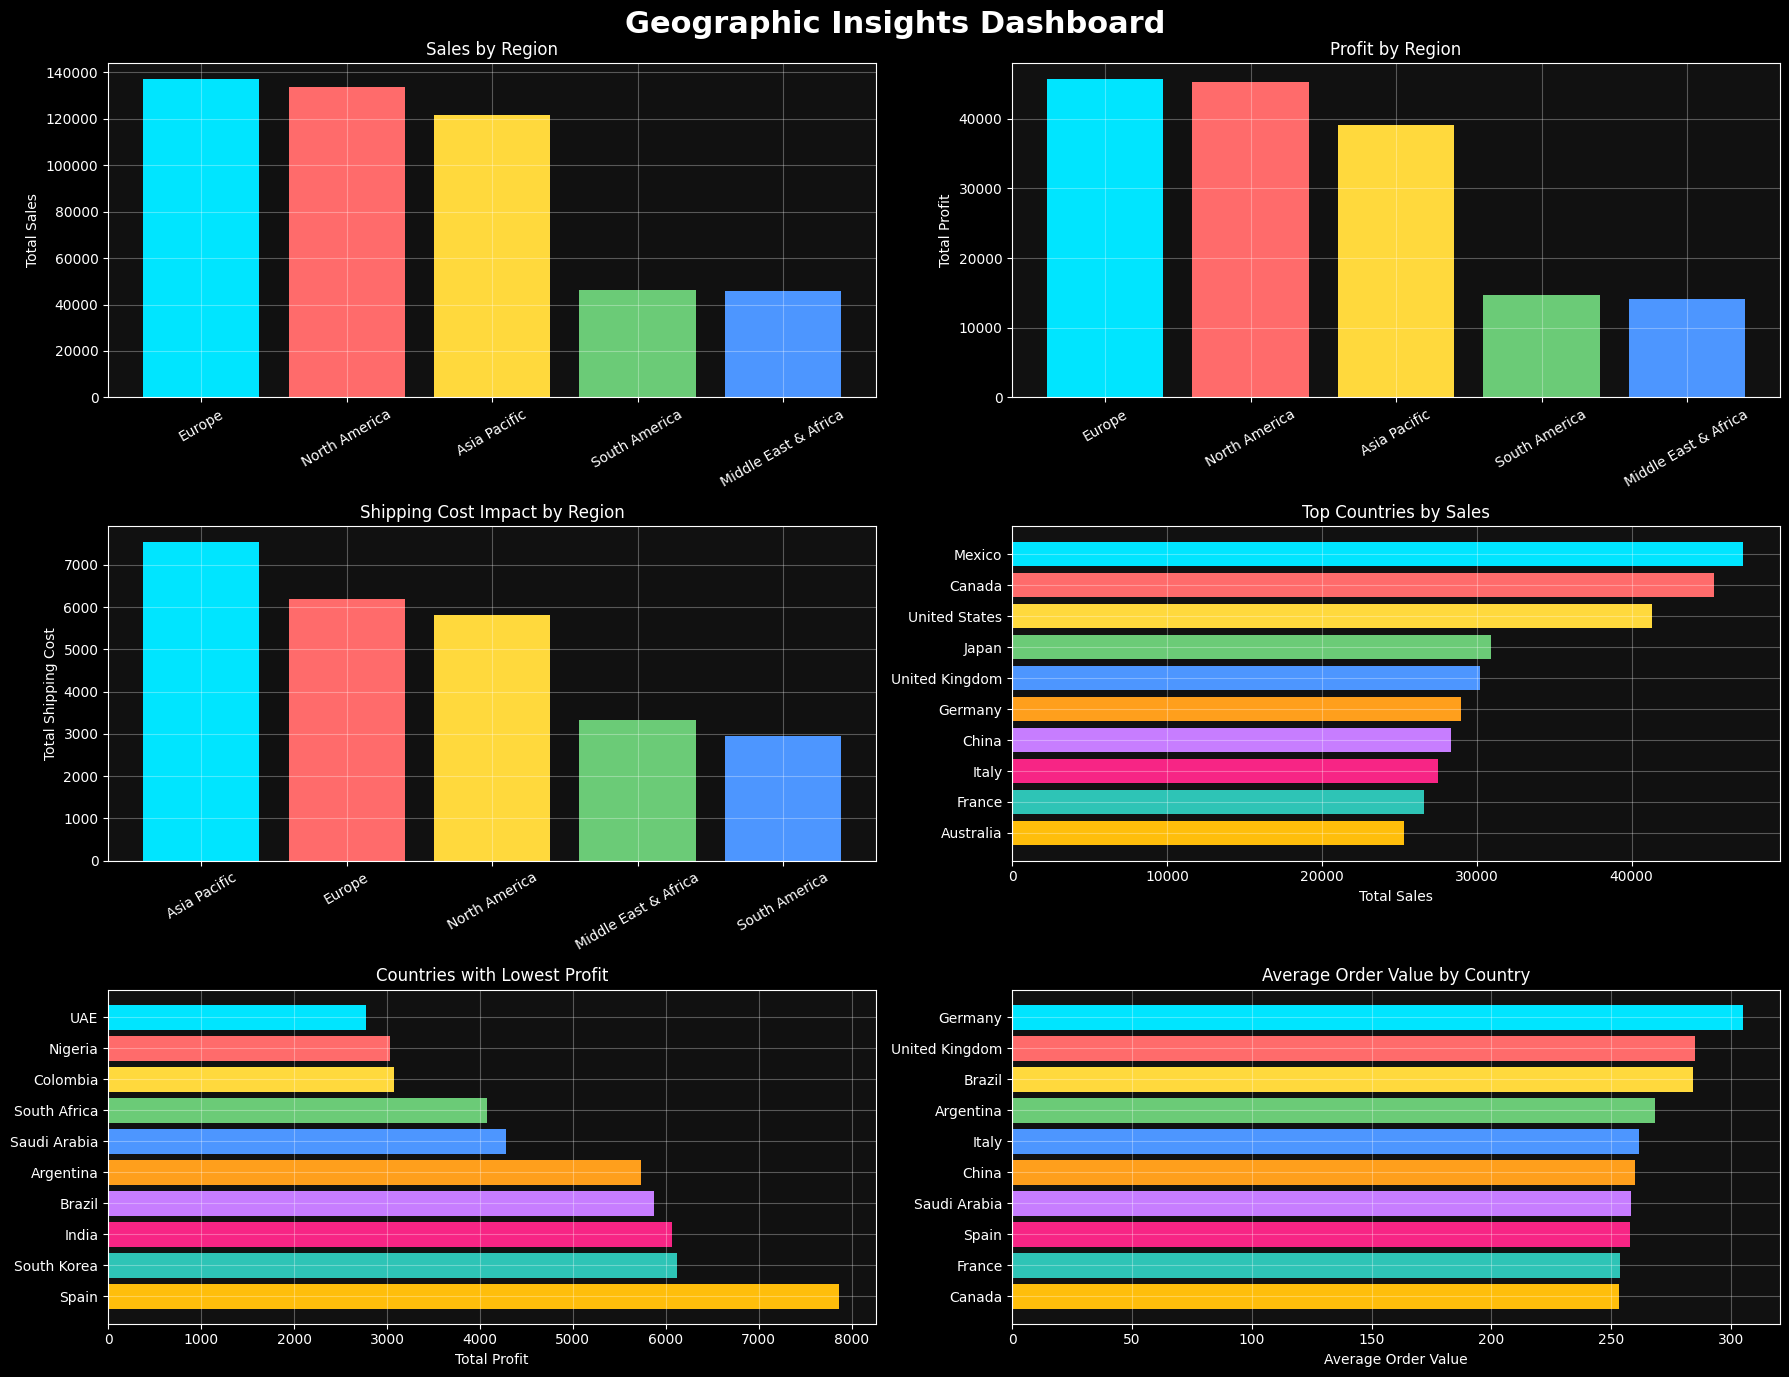

In [7]:
# ----- Geographic Aggregations -----

region_sales = df.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_shipping = df.groupby("Region")["Shipping_Cost"].sum().sort_values(ascending=False)
top_countries_sales = (
    df.groupby("Country")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

lowest_profit_countries = (
    df.groupby("Country")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

country_aov = (
    df.groupby("Country")["Total_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# ----- Dashboard Layout -----

fig, axes = plt.subplots(3,2, figsize=(18,14))

fig.suptitle(
    "Geographic Insights Dashboard",
    fontsize=22,
    fontweight="bold"
)

# -------- Sales by Region --------

ax = axes[0,0]

ax.bar(
    region_sales.index,
    region_sales.values,
    color=bright_colors
)

ax.set_title("Sales by Region")
ax.set_ylabel("Total Sales")
ax.tick_params(axis="x", rotation=30)

# -------- Profit by Region --------

ax = axes[0,1]

ax.bar(
    region_profit.index,
    region_profit.values,
    color=bright_colors
)

ax.set_title("Profit by Region")
ax.set_ylabel("Total Profit")
ax.tick_params(axis="x", rotation=30)

# -------- Shipping Cost by Region --------

ax = axes[1,0]

ax.bar(
    region_shipping.index,
    region_shipping.values,
    color=bright_colors
)

ax.set_title("Shipping Cost Impact by Region")
ax.set_ylabel("Total Shipping Cost")
ax.tick_params(axis="x", rotation=30)

# -------- Top Countries by Sales --------

ax = axes[1,1]

ax.barh(
    top_countries_sales.index,
    top_countries_sales.values,
    color=bright_colors
)

ax.set_title("Top Countries by Sales")
ax.set_xlabel("Total Sales")
ax.invert_yaxis()

# -------- Countries with Lowest Profit --------

ax = axes[2,0]

ax.barh(
    lowest_profit_countries.index,
    lowest_profit_countries.values,
    color=bright_colors
)

ax.set_title("Countries with Lowest Profit")
ax.set_xlabel("Total Profit")
ax.invert_yaxis()

# -------- Average Order Value by Country --------

ax = axes[2,1]

ax.barh(
    country_aov.index,
    country_aov.values,
    color=bright_colors
)

ax.set_title("Average Order Value by Country")
ax.set_xlabel("Average Order Value")
ax.invert_yaxis()

# ----- Styling -----

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")

plt.tight_layout()
plt.show()

# **3️⃣ Customer Behavior Insights**

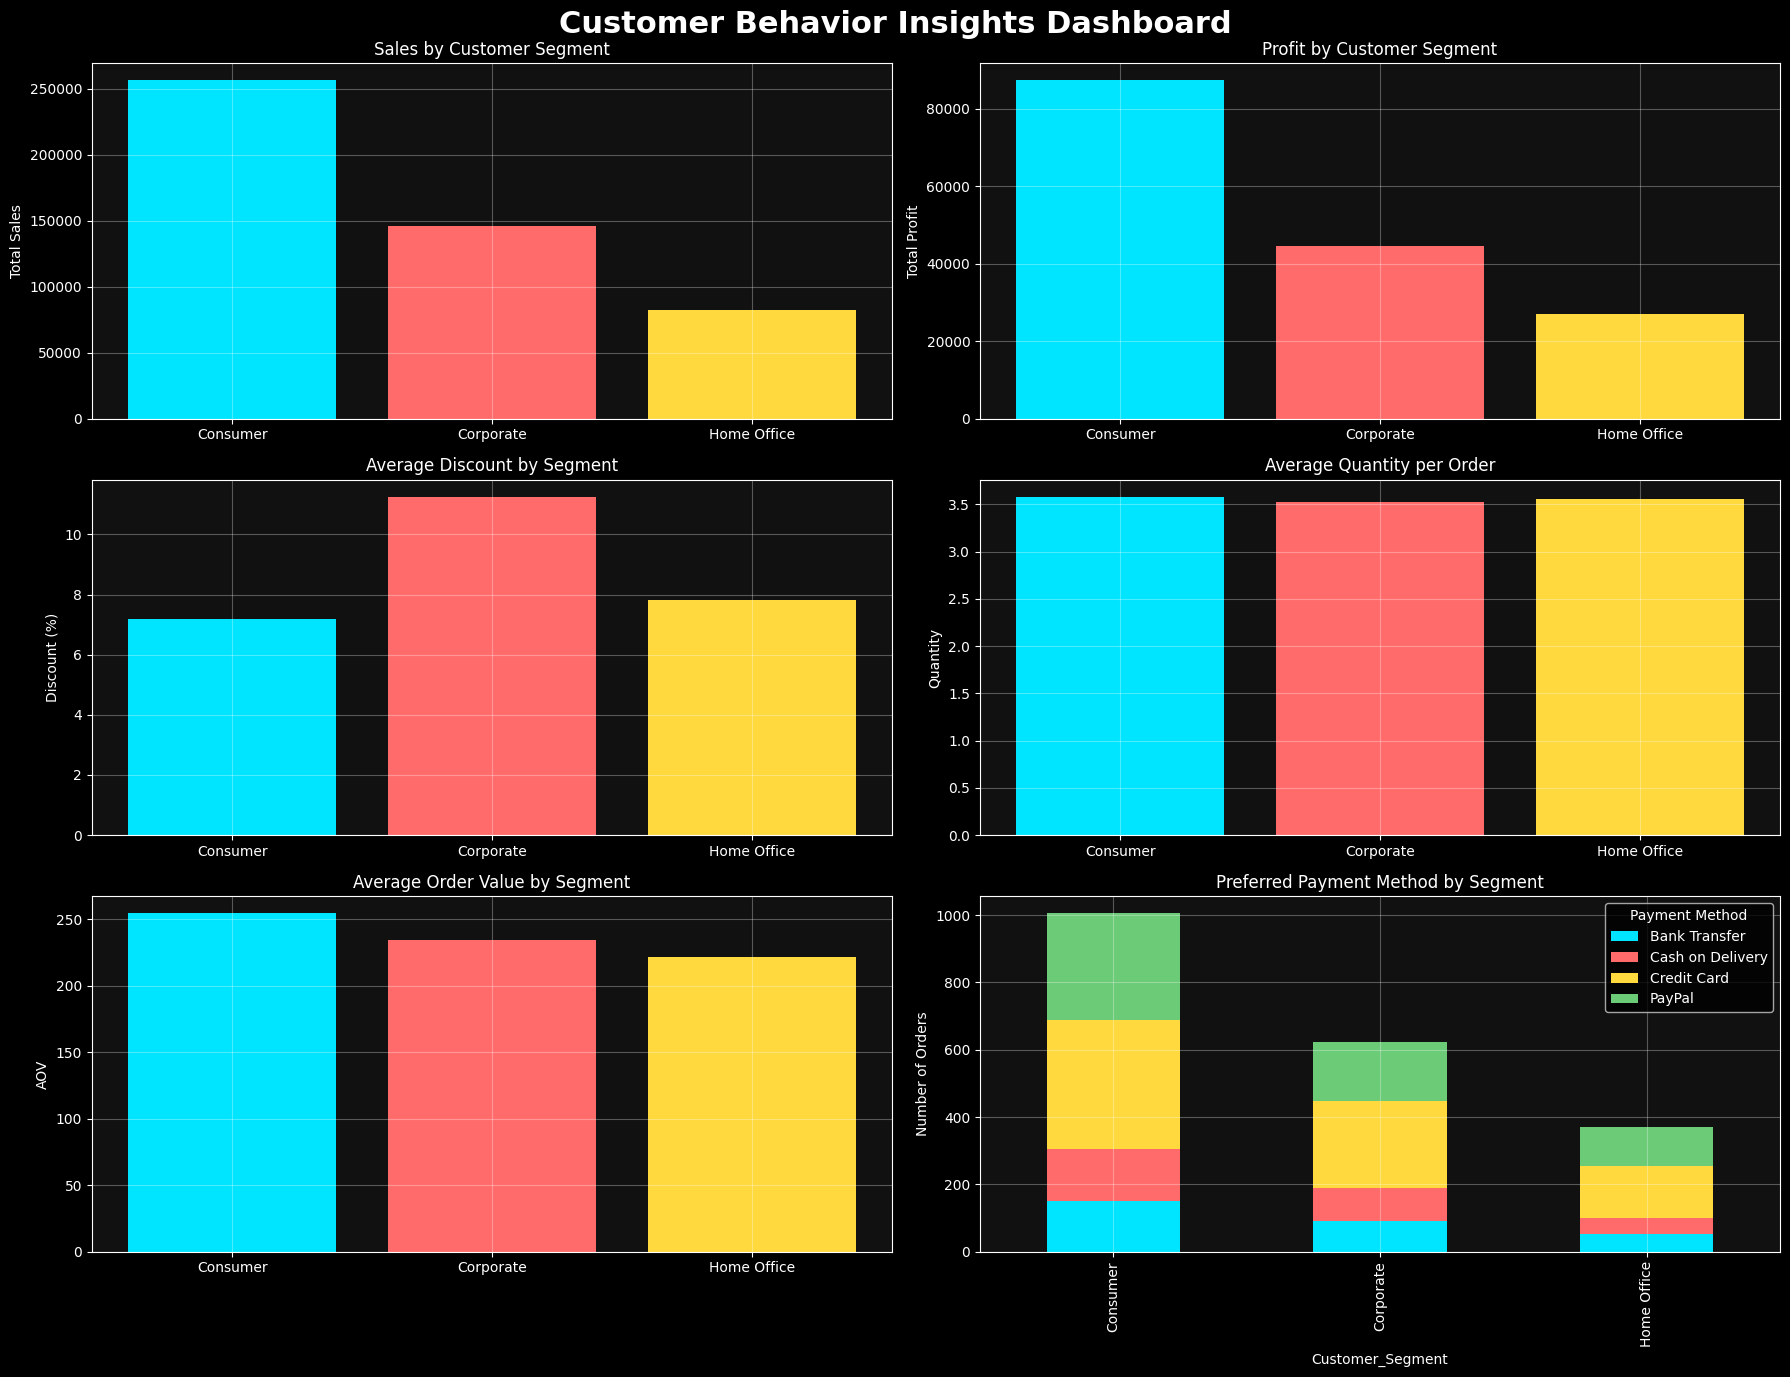

In [8]:
# ----- Customer Segment Aggregations -----

segment_sales = df.groupby("Customer_Segment")["Total_Sales"].sum()
segment_profit = df.groupby("Customer_Segment")["Profit"].sum()
segment_discount = df.groupby("Customer_Segment")["Discount_Percent"].mean()
segment_quantity = df.groupby("Customer_Segment")["Quantity"].mean()
segment_aov = df.groupby("Customer_Segment")["Total_Sales"].mean()
payment_segment = (
    df.groupby(["Customer_Segment","Payment_Method"])
    .size()
    .unstack()
)

# ----- Dashboard Layout -----

fig, axes = plt.subplots(3,2, figsize=(18,14))

fig.suptitle(
    "Customer Behavior Insights Dashboard",
    fontsize=22,
    fontweight="bold"
)

# -------- Sales by Segment --------

ax = axes[0,0]

ax.bar(
    segment_sales.index,
    segment_sales.values,
    color=bright_colors[:3]
)

ax.set_title("Sales by Customer Segment")
ax.set_ylabel("Total Sales")

# -------- Profit by Segment --------

ax = axes[0,1]

ax.bar(
    segment_profit.index,
    segment_profit.values,
    color=bright_colors[:3]
)

ax.set_title("Profit by Customer Segment")
ax.set_ylabel("Total Profit")

# -------- Average Discount --------

ax = axes[1,0]

ax.bar(
    segment_discount.index,
    segment_discount.values,
    color=bright_colors[:3]
)

ax.set_title("Average Discount by Segment")
ax.set_ylabel("Discount (%)")

# -------- Average Quantity --------

ax = axes[1,1]

ax.bar(
    segment_quantity.index,
    segment_quantity.values,
    color=bright_colors[:3]
)

ax.set_title("Average Quantity per Order")
ax.set_ylabel("Quantity")

# -------- Average Order Value --------

ax = axes[2,0]

ax.bar(
    segment_aov.index,
    segment_aov.values,
    color=bright_colors[:3]
)

ax.set_title("Average Order Value by Segment")
ax.set_ylabel("AOV")

# -------- Payment Method by Segment --------

ax = axes[2,1]

payment_segment.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=bright_colors
)

ax.set_title("Preferred Payment Method by Segment")
ax.set_ylabel("Number of Orders")
ax.legend(title="Payment Method")

# ----- Styling -----

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")

plt.tight_layout()
plt.show()

# **4️⃣ Product Performance Insights**

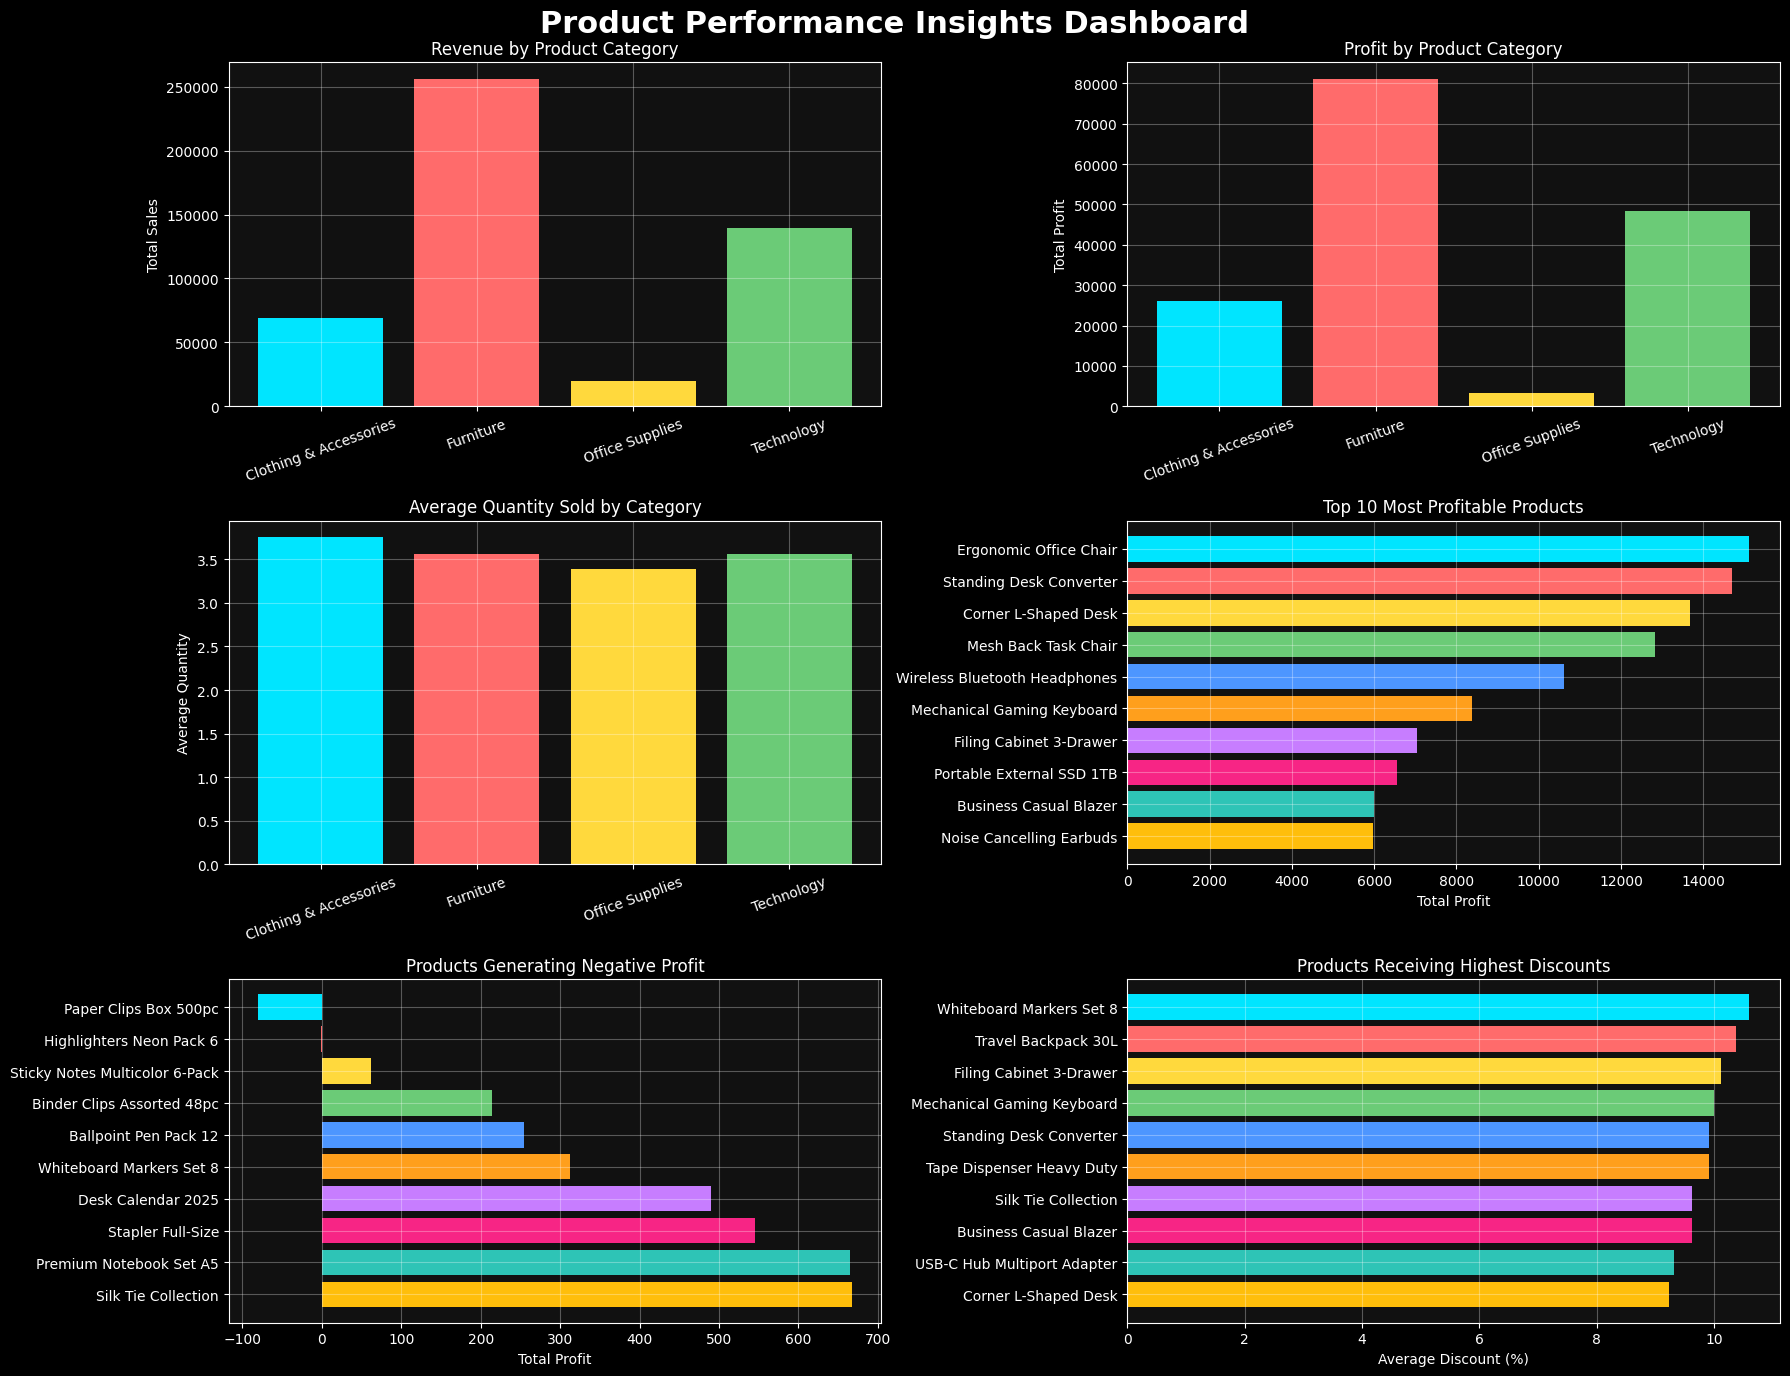

In [9]:
# ----- Category Aggregations -----

category_sales = df.groupby("Product_Category")["Total_Sales"].sum()
category_profit = df.groupby("Product_Category")["Profit"].sum()
category_quantity = df.groupby("Product_Category")["Quantity"].mean()


# ----- Product-Level Analysis -----

top_profit_products = (
    df.groupby("Product_Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

negative_profit_products = (
    df.groupby("Product_Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

highest_discount_products = (
    df.groupby("Product_Name")["Discount_Percent"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# ----- Dashboard Layout -----

fig, axes = plt.subplots(3,2, figsize=(18,14))

fig.suptitle(
    "Product Performance Insights Dashboard",
    fontsize=22,
    fontweight="bold"
)

# -------- Revenue by Category --------

ax = axes[0,0]

ax.bar(
    category_sales.index,
    category_sales.values,
    color=bright_colors[:4]
)

ax.set_title("Revenue by Product Category")
ax.set_ylabel("Total Sales")
ax.tick_params(axis="x", rotation=20)

# -------- Profit by Category --------

ax = axes[0,1]

ax.bar(
    category_profit.index,
    category_profit.values,
    color=bright_colors[:4]
)

ax.set_title("Profit by Product Category")
ax.set_ylabel("Total Profit")
ax.tick_params(axis="x", rotation=20)

# -------- Average Quantity --------

ax = axes[1,0]

ax.bar(
    category_quantity.index,
    category_quantity.values,
    color=bright_colors[:4]
)

ax.set_title("Average Quantity Sold by Category")
ax.set_ylabel("Average Quantity")
ax.tick_params(axis="x", rotation=20)

# -------- Top Profitable Products --------

ax = axes[1,1]

ax.barh(
    top_profit_products.index,
    top_profit_products.values,
    color=bright_colors
)

ax.set_title("Top 10 Most Profitable Products")
ax.set_xlabel("Total Profit")
ax.invert_yaxis()

# -------- Negative Profit Products --------

ax = axes[2,0]

ax.barh(
    negative_profit_products.index,
    negative_profit_products.values,
    color=bright_colors
)

ax.set_title("Products Generating Negative Profit")
ax.set_xlabel("Total Profit")
ax.invert_yaxis()

# -------- Highest Discount Products --------

ax = axes[2,1]

ax.barh(
    highest_discount_products.index,
    highest_discount_products.values,
    color=bright_colors
)

ax.set_title("Products Receiving Highest Discounts")
ax.set_xlabel("Average Discount (%)")
ax.invert_yaxis()

# ----- Styling -----

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")

plt.tight_layout()
plt.show()

# **5️⃣ Discount Strategy Analysis**

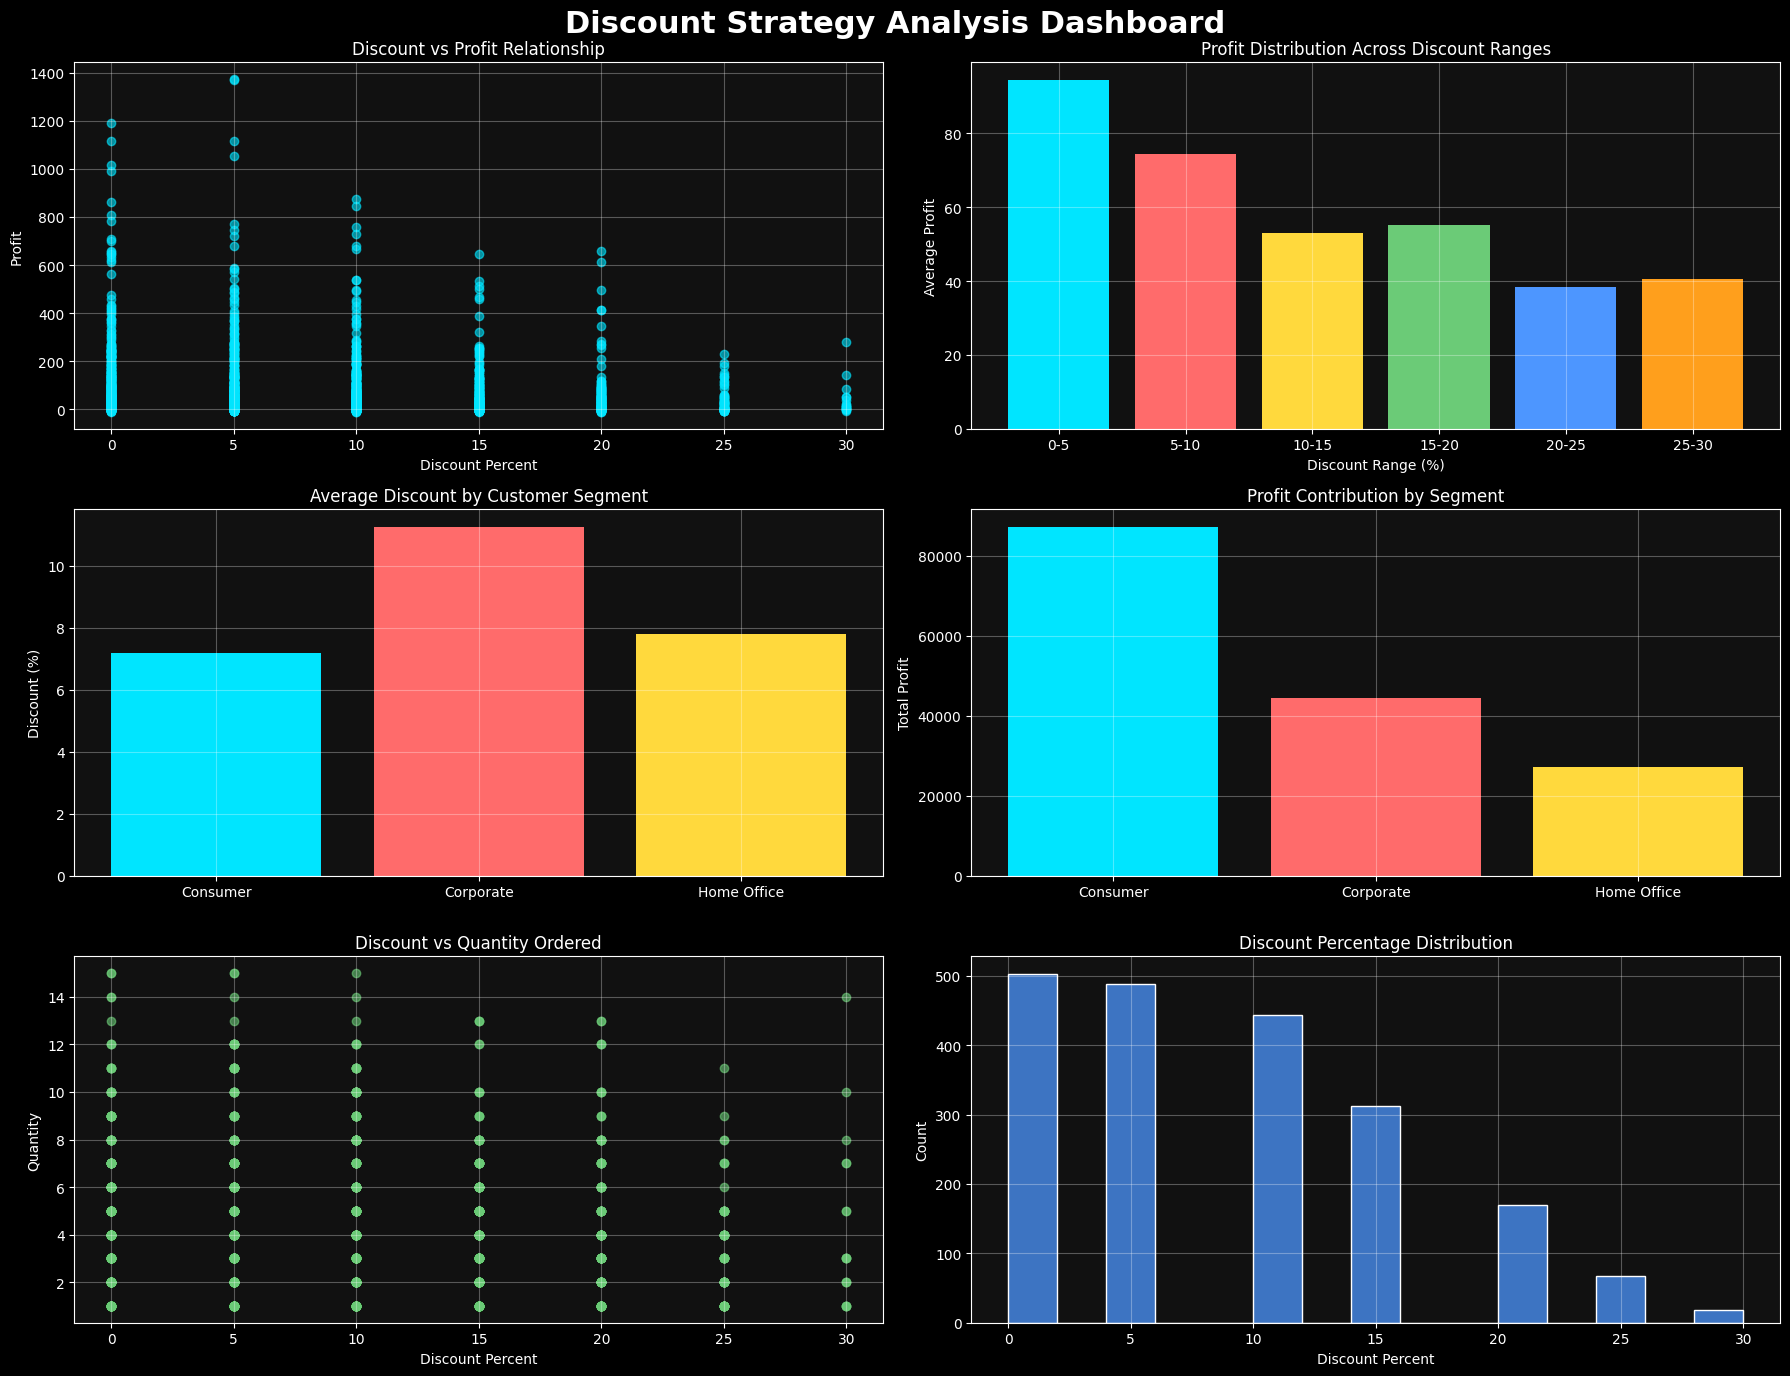

In [10]:
# ----- Create Discount Range Feature -----

df["Discount_Range"] = pd.cut(
    df["Discount_Percent"],
    bins=[0,5,10,15,20,25,30],
    labels=["0-5","5-10","10-15","15-20","20-25","25-30"]
)

# ----- Segment Metrics -----

segment_discount = df.groupby("Customer_Segment")["Discount_Percent"].mean()
segment_profit = df.groupby("Customer_Segment")["Profit"].sum()
profit_by_discount = df.groupby("Discount_Range")["Profit"].mean()

# ----- Dashboard Layout -----

fig, axes = plt.subplots(3,2, figsize=(18,14))

fig.suptitle(
    "Discount Strategy Analysis Dashboard",
    fontsize=22,
    fontweight="bold"
)

# -------- Discount vs Profit Scatter --------

ax = axes[0,0]

ax.scatter(
    df["Discount_Percent"],
    df["Profit"],
    color=bright_colors[0],
    alpha=0.6
)

ax.set_title("Discount vs Profit Relationship")
ax.set_xlabel("Discount Percent")
ax.set_ylabel("Profit")

# -------- Profit by Discount Range --------

ax = axes[0,1]

ax.bar(
    profit_by_discount.index.astype(str),
    profit_by_discount.values,
    color=bright_colors
)

ax.set_title("Profit Distribution Across Discount Ranges")
ax.set_xlabel("Discount Range (%)")
ax.set_ylabel("Average Profit")

# -------- Average Discount by Segment --------

ax = axes[1,0]

ax.bar(
    segment_discount.index,
    segment_discount.values,
    color=bright_colors[:3]
)

ax.set_title("Average Discount by Customer Segment")
ax.set_ylabel("Discount (%)")

# -------- Profit Contribution by Segment --------

ax = axes[1,1]

ax.bar(
    segment_profit.index,
    segment_profit.values,
    color=bright_colors[:3]
)

ax.set_title("Profit Contribution by Segment")
ax.set_ylabel("Total Profit")

# -------- Discount vs Quantity --------

ax = axes[2,0]

ax.scatter(
    df["Discount_Percent"],
    df["Quantity"],
    color=bright_colors[3],
    alpha=0.6
)

ax.set_title("Discount vs Quantity Ordered")
ax.set_xlabel("Discount Percent")
ax.set_ylabel("Quantity")

# -------- Discount Distribution --------

ax = axes[2,1]

sns.histplot(
    df["Discount_Percent"],
    bins=15,
    color=bright_colors[4],
    ax=ax
)

ax.set_title("Discount Percentage Distribution")
ax.set_xlabel("Discount Percent")

# ----- Styling -----

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")

plt.tight_layout()
plt.show()

# **6️⃣ Time-Based Insights**

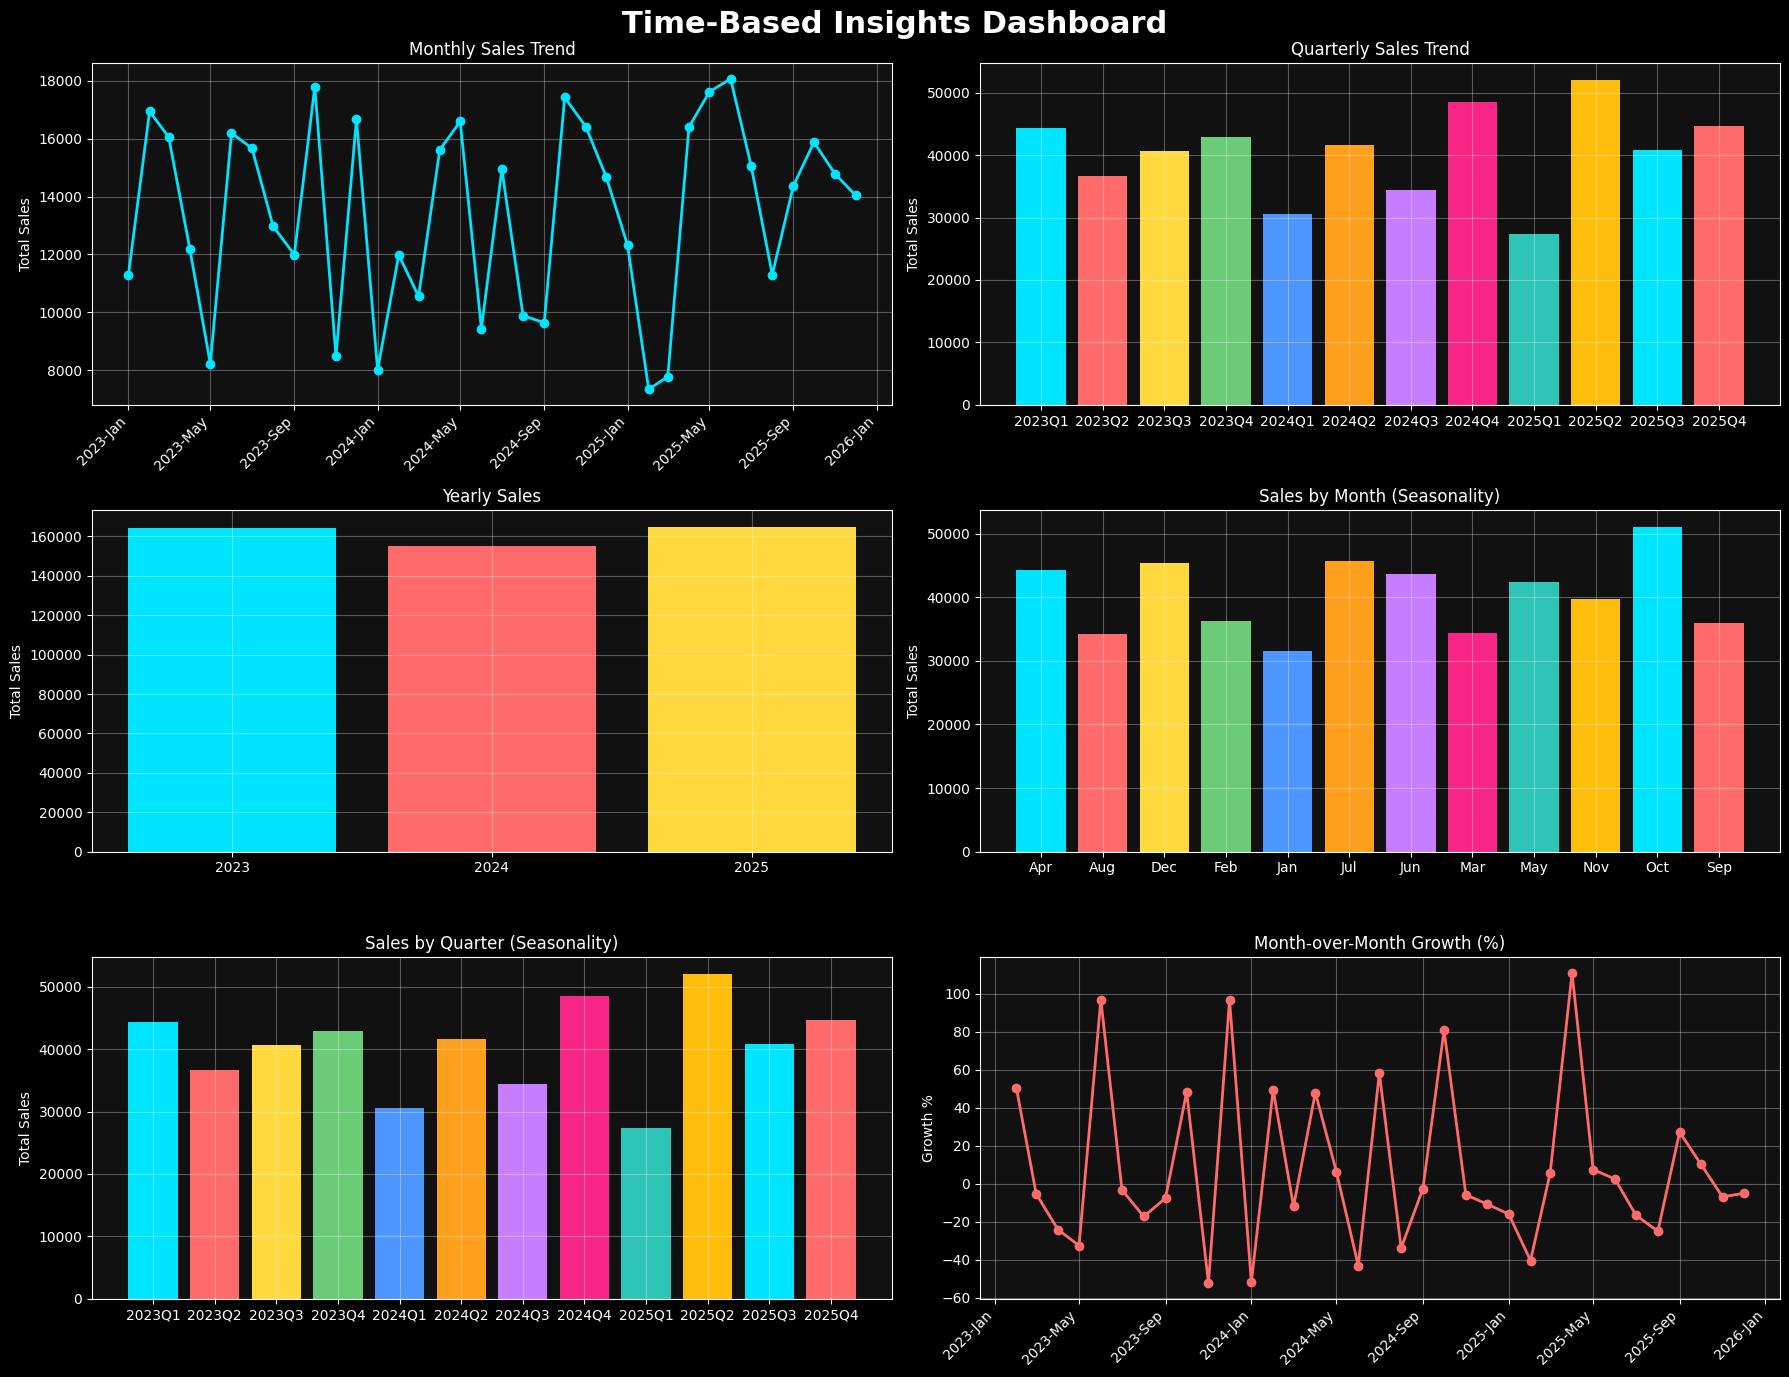

In [11]:
# ---------- Convert Order_Date to datetime ----------
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# ---------- Extract time features ----------
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Quarter"] = df["Order_Date"].dt.to_period("Q")
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")
df["Month_Date"] = df["Order_Date"].values.astype('datetime64[M]')  # first day of month

# ---------- Aggregations ----------
monthly_sales = df.groupby(["Year","Month"]).agg(Total_Sales=("Total_Sales","sum")).reset_index()
monthly_sales["Month_Date"] = pd.to_datetime(dict(year=monthly_sales["Year"], month=monthly_sales["Month"], day=1))

quarterly_sales = df.groupby("Quarter")["Total_Sales"].sum()
yearly_sales = df.groupby("Year")["Total_Sales"].sum()

month_seasonality = df.groupby("Month_Name")["Total_Sales"].sum()
quarter_seasonality = df.groupby("Quarter")["Total_Sales"].sum()

mom_growth = monthly_sales.copy()
mom_growth["MoM_Growth"] = mom_growth["Total_Sales"].pct_change() * 100

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(3,2, figsize=(18,14))
fig.suptitle("Time-Based Insights Dashboard", fontsize=22, fontweight="bold")

# -------- Monthly Sales Trend --------
ax = axes[0,0]
ax.plot(
    monthly_sales["Month_Date"],
    monthly_sales["Total_Sales"],
    color=bright_colors[0],
    marker="o",
    linewidth=2
)
ax.set_title("Monthly Sales Trend")
ax.set_ylabel("Total Sales")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%b"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# -------- Quarterly Sales Trend --------
ax = axes[0,1]
ax.bar(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    color=bright_colors
)
ax.set_title("Quarterly Sales Trend")
ax.set_ylabel("Total Sales")

# -------- Yearly Sales --------
ax = axes[1,0]
ax.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values,
    color=bright_colors
)
ax.set_title("Yearly Sales")
ax.set_ylabel("Total Sales")

# -------- Monthly Seasonality --------
ax = axes[1,1]
ax.bar(
    month_seasonality.index,
    month_seasonality.values,
    color=bright_colors
)
ax.set_title("Sales by Month (Seasonality)")
ax.set_ylabel("Total Sales")

# -------- Quarterly Seasonality --------
ax = axes[2,0]
ax.bar(
    quarter_seasonality.index.astype(str),
    quarter_seasonality.values,
    color=bright_colors
)
ax.set_title("Sales by Quarter (Seasonality)")
ax.set_ylabel("Total Sales")

# -------- Month-over-Month Growth --------
ax = axes[2,1]
ax.plot(
    monthly_sales["Month_Date"],
    mom_growth["MoM_Growth"],
    color=bright_colors[1],
    marker="o",
    linewidth=2
)
ax.set_title("Month-over-Month Growth (%)")
ax.set_ylabel("Growth %")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%b"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **7️⃣ Payment Method Analysis**

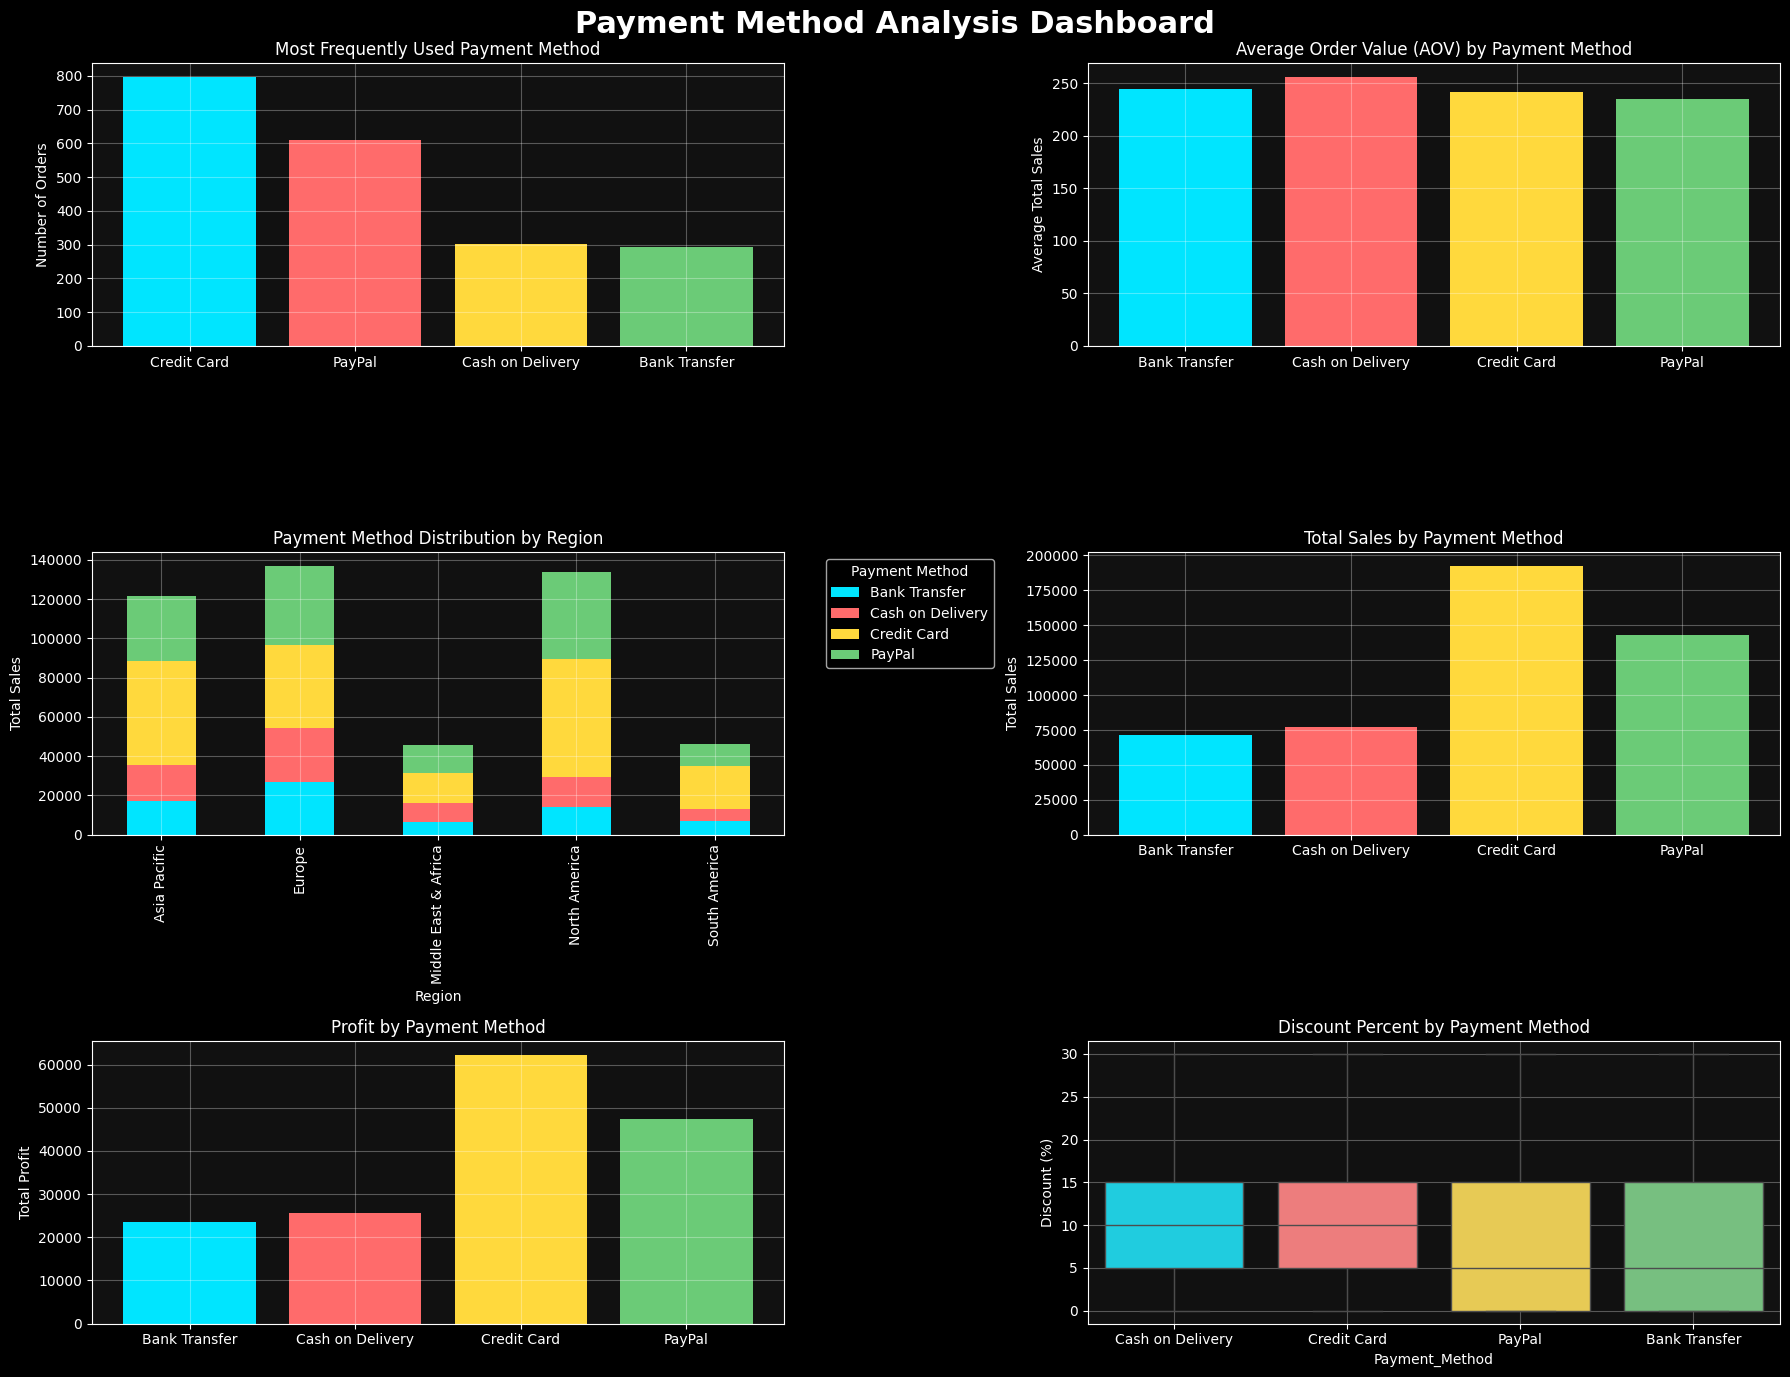

In [12]:
# ---------- Calculate Metrics ----------
# Count of orders per payment method
payment_counts = df["Payment_Method"].value_counts()

# Average order value (AOV) by payment method
aov_payment = df.groupby("Payment_Method")["Total_Sales"].mean()

# Profit by payment method
profit_payment = df.groupby("Payment_Method")["Profit"].sum()

# Total sales by payment method
sales_payment = df.groupby("Payment_Method")["Total_Sales"].sum()

# Payment method by region (stacked)
region_payment = df.groupby(["Region","Payment_Method"])["Total_Sales"].sum().unstack().fillna(0)

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(3,2, figsize=(18,14))
fig.suptitle("Payment Method Analysis Dashboard", fontsize=22, fontweight="bold")

# -------- Payment Method Counts --------
ax = axes[0,0]
ax.bar(payment_counts.index, payment_counts.values, color=bright_colors[:4])
ax.set_title("Most Frequently Used Payment Method")
ax.set_ylabel("Number of Orders")

# -------- Average Order Value by Payment Method --------
ax = axes[0,1]
ax.bar(aov_payment.index, aov_payment.values, color=bright_colors[:4])
ax.set_title("Average Order Value (AOV) by Payment Method")
ax.set_ylabel("Average Total Sales")

# -------- Payment Method by Region (Stacked) --------
ax = axes[1,0]
region_payment.plot(kind="bar", stacked=True, ax=ax, color=bright_colors[:len(region_payment.columns)])
ax.set_title("Payment Method Distribution by Region")
ax.set_ylabel("Total Sales")
ax.legend(title="Payment Method", bbox_to_anchor=(1.05,1), loc="upper left")

# -------- Total Sales by Payment Method --------
ax = axes[1,1]
ax.bar(sales_payment.index, sales_payment.values, color=bright_colors[:4])
ax.set_title("Total Sales by Payment Method")
ax.set_ylabel("Total Sales")

# -------- Profit by Payment Method --------
ax = axes[2,0]
ax.bar(profit_payment.index, profit_payment.values, color=bright_colors[:4])
ax.set_title("Profit by Payment Method")
ax.set_ylabel("Total Profit")

# -------- Optional: Discount vs Payment Method --------
ax = axes[2,1]
sns.boxplot(x="Payment_Method", y="Discount_Percent", data=df, palette=bright_colors[:4], ax=ax)
ax.set_title("Discount Percent by Payment Method")
ax.set_ylabel("Discount (%)")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **8️⃣ Shipping Cost Impact**

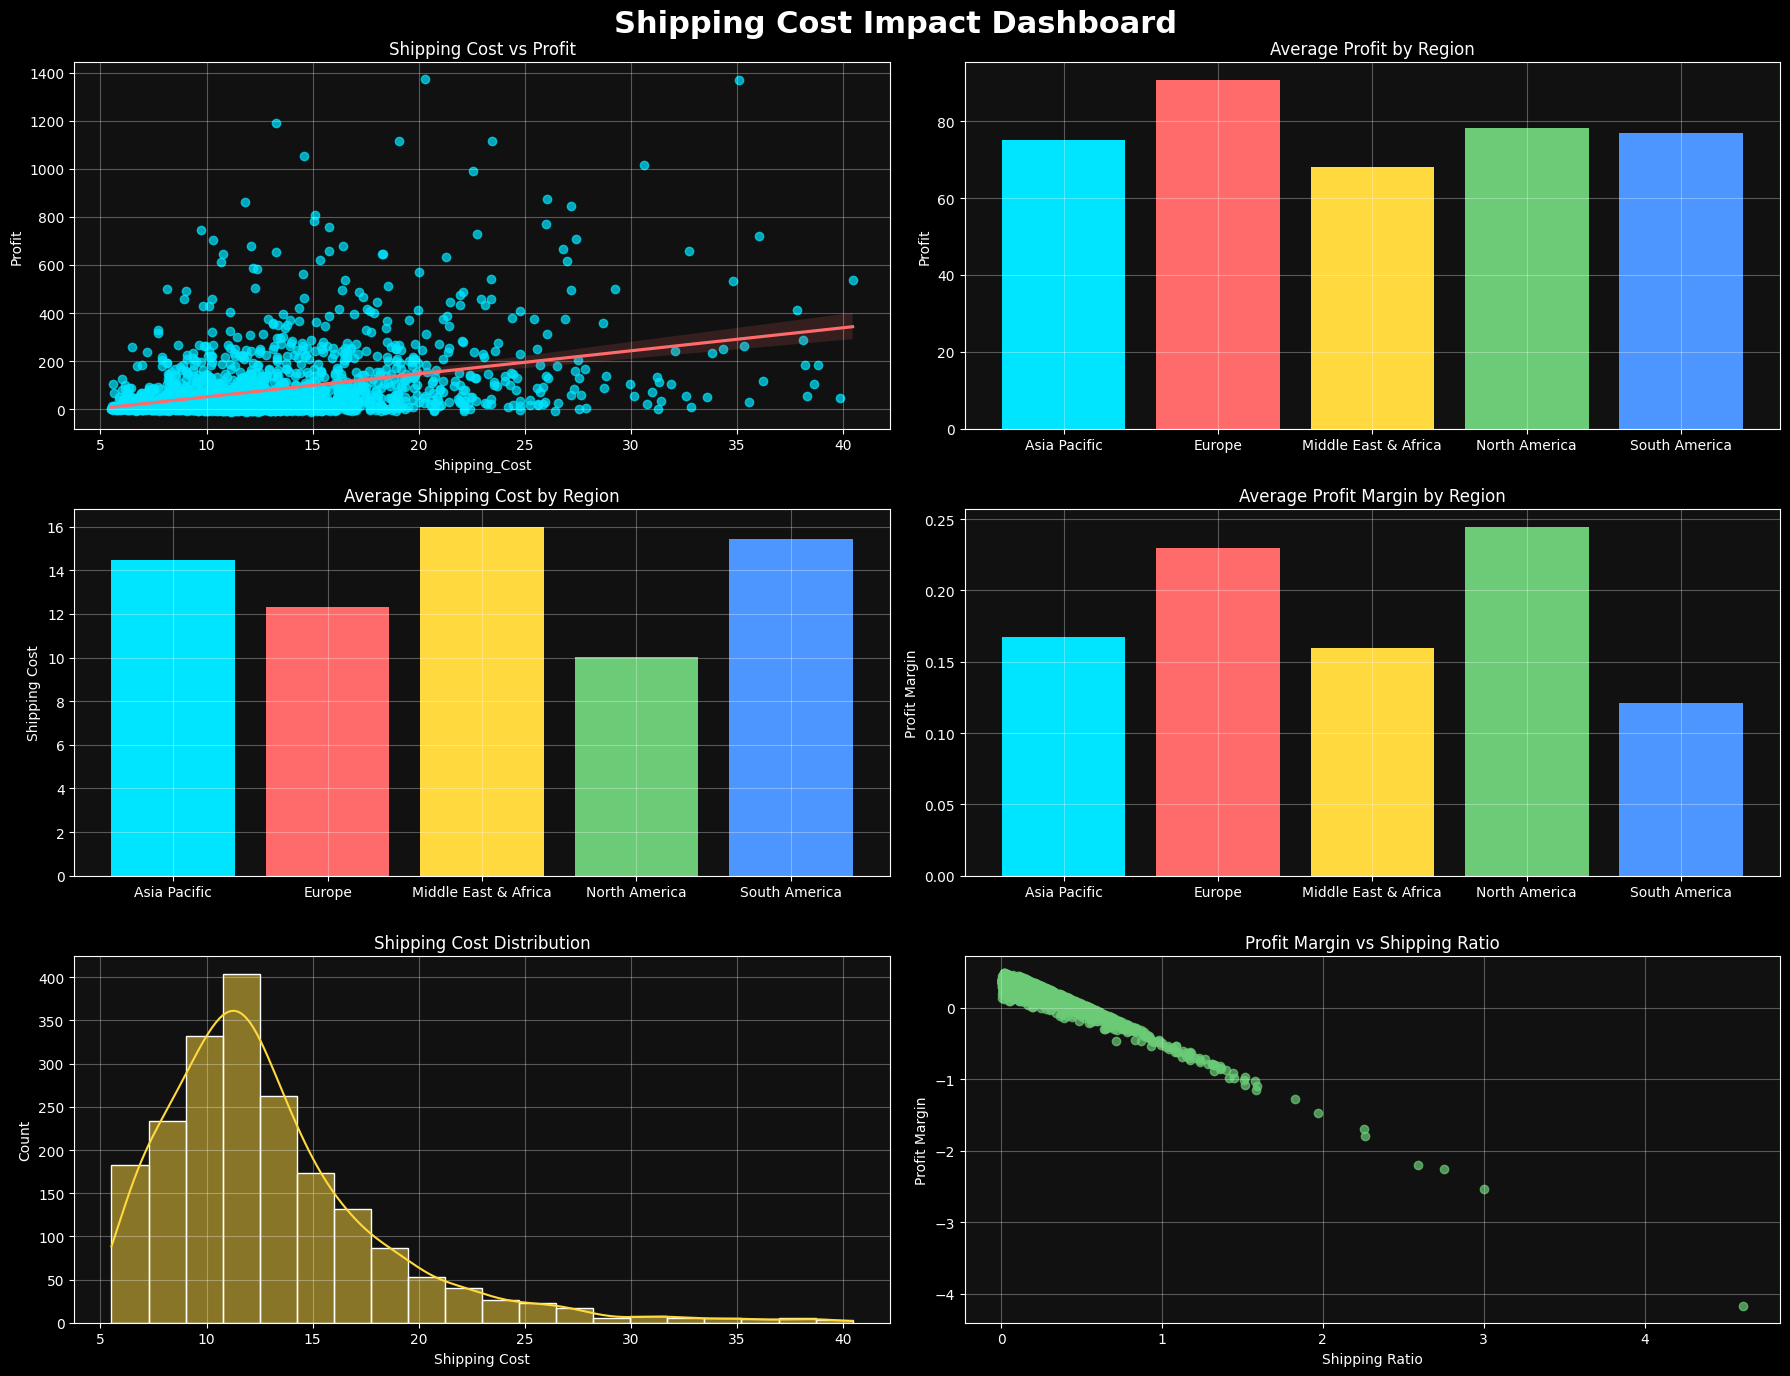

In [13]:
# ---------- Compute Metrics ----------
# Profit margin
df["Profit_Margin"] = df["Profit"] / df["Total_Sales"]

# Shipping ratio
df["Shipping_Ratio"] = df["Shipping_Cost"] / df["Total_Sales"]

# Average profit by region
profit_region = df.groupby("Region")["Profit"].mean()

# Average shipping cost by region
shipping_region = df.groupby("Region")["Shipping_Cost"].mean()

# Average profit margin by region
profit_margin_region = df.groupby("Region")["Profit_Margin"].mean()

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(3,2, figsize=(18,14))
fig.suptitle("Shipping Cost Impact Dashboard", fontsize=22, fontweight="bold")

# -------- Shipping Cost vs Profit (Scatter) --------
ax = axes[0,0]
ax.scatter(df["Shipping_Cost"], df["Profit"], c=bright_colors[0], alpha=0.7)
ax.set_title("Shipping Cost vs Profit")
ax.set_xlabel("Shipping Cost")
ax.set_ylabel("Profit")

# Optional: regression line
sns.regplot(x="Shipping_Cost", y="Profit", data=df, scatter=False, ax=ax, color=bright_colors[1])

# -------- Average Profit by Region --------
ax = axes[0,1]
ax.bar(profit_region.index, profit_region.values, color=bright_colors[:len(profit_region)])
ax.set_title("Average Profit by Region")
ax.set_ylabel("Profit")

# -------- Average Shipping Cost by Region --------
ax = axes[1,0]
ax.bar(shipping_region.index, shipping_region.values, color=bright_colors[:len(shipping_region)])
ax.set_title("Average Shipping Cost by Region")
ax.set_ylabel("Shipping Cost")

# -------- Profit Margin by Region --------
ax = axes[1,1]
ax.bar(profit_margin_region.index, profit_margin_region.values, color=bright_colors[:len(profit_margin_region)])
ax.set_title("Average Profit Margin by Region")
ax.set_ylabel("Profit Margin")

# -------- Shipping Cost Distribution --------
ax = axes[2,0]
sns.histplot(df["Shipping_Cost"], bins=20, kde=True, color=bright_colors[2], ax=ax)
ax.set_title("Shipping Cost Distribution")
ax.set_xlabel("Shipping Cost")

# -------- Profit Margin vs Shipping Ratio --------
ax = axes[2,1]
ax.scatter(df["Shipping_Ratio"], df["Profit_Margin"], c=bright_colors[3], alpha=0.7)
ax.set_title("Profit Margin vs Shipping Ratio")
ax.set_xlabel("Shipping Ratio")
ax.set_ylabel("Profit Margin")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **9️⃣ Order Value Insights**

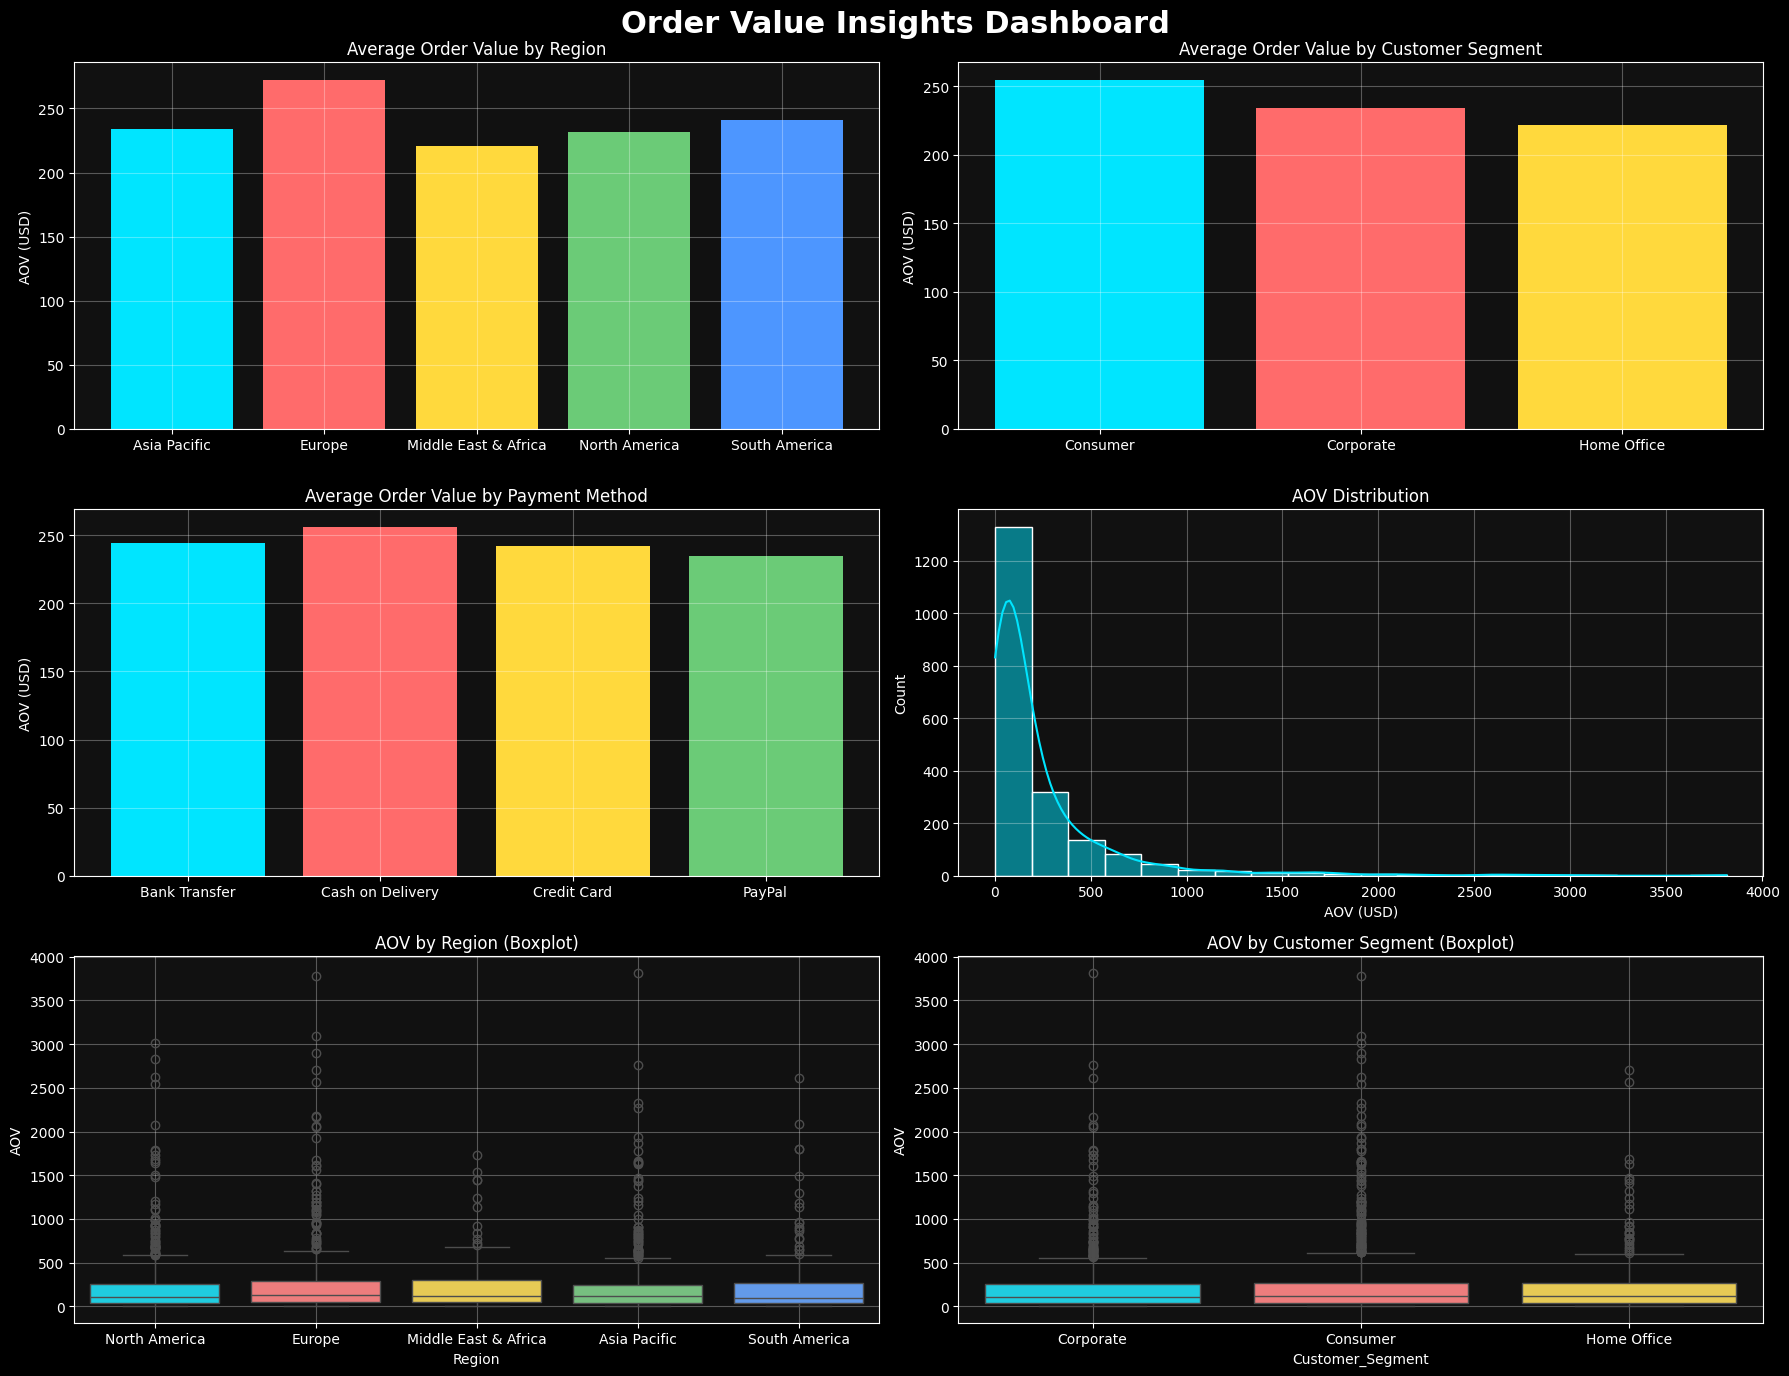

In [14]:
# ---------- Compute Metrics ----------
# Average Order Value (AOV) by Region
aov_region = df.groupby("Region")["Total_Sales"].mean()

# Average Order Value (AOV) by Customer Segment
aov_segment = df.groupby("Customer_Segment")["Total_Sales"].mean()

# Average Order Value (AOV) by Payment Method
aov_payment = df.groupby("Payment_Method")["Total_Sales"].mean()

# Optional: Histogram of AOV
df["AOV"] = df["Total_Sales"]  # since each row is one order, Total_Sales = order value

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(3,2, figsize=(18,14))
fig.suptitle("Order Value Insights Dashboard", fontsize=22, fontweight="bold")

# -------- AOV by Region --------
ax = axes[0,0]
ax.bar(aov_region.index, aov_region.values, color=bright_colors[:len(aov_region)])
ax.set_title("Average Order Value by Region")
ax.set_ylabel("AOV (USD)")

# -------- AOV by Customer Segment --------
ax = axes[0,1]
ax.bar(aov_segment.index, aov_segment.values, color=bright_colors[:len(aov_segment)])
ax.set_title("Average Order Value by Customer Segment")
ax.set_ylabel("AOV (USD)")

# -------- AOV by Payment Method --------
ax = axes[1,0]
ax.bar(aov_payment.index, aov_payment.values, color=bright_colors[:len(aov_payment)])
ax.set_title("Average Order Value by Payment Method")
ax.set_ylabel("AOV (USD)")

# -------- AOV Distribution Histogram --------
ax = axes[1,1]
sns.histplot(df["AOV"], bins=20, kde=True, color=bright_colors[0], ax=ax)
ax.set_title("AOV Distribution")
ax.set_xlabel("AOV (USD)")

# -------- Optional: Boxplot AOV by Region --------
ax = axes[2,0]
sns.boxplot(x="Region", y="AOV", data=df, palette=bright_colors[:len(aov_region)], ax=ax)
ax.set_title("AOV by Region (Boxplot)")

# -------- Optional: Boxplot AOV by Customer Segment --------
ax = axes[2,1]
sns.boxplot(x="Customer_Segment", y="AOV", data=df, palette=bright_colors[:len(aov_segment)], ax=ax)
ax.set_title("AOV by Customer Segment (Boxplot)")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **🔟 Advanced Analytical Insights**

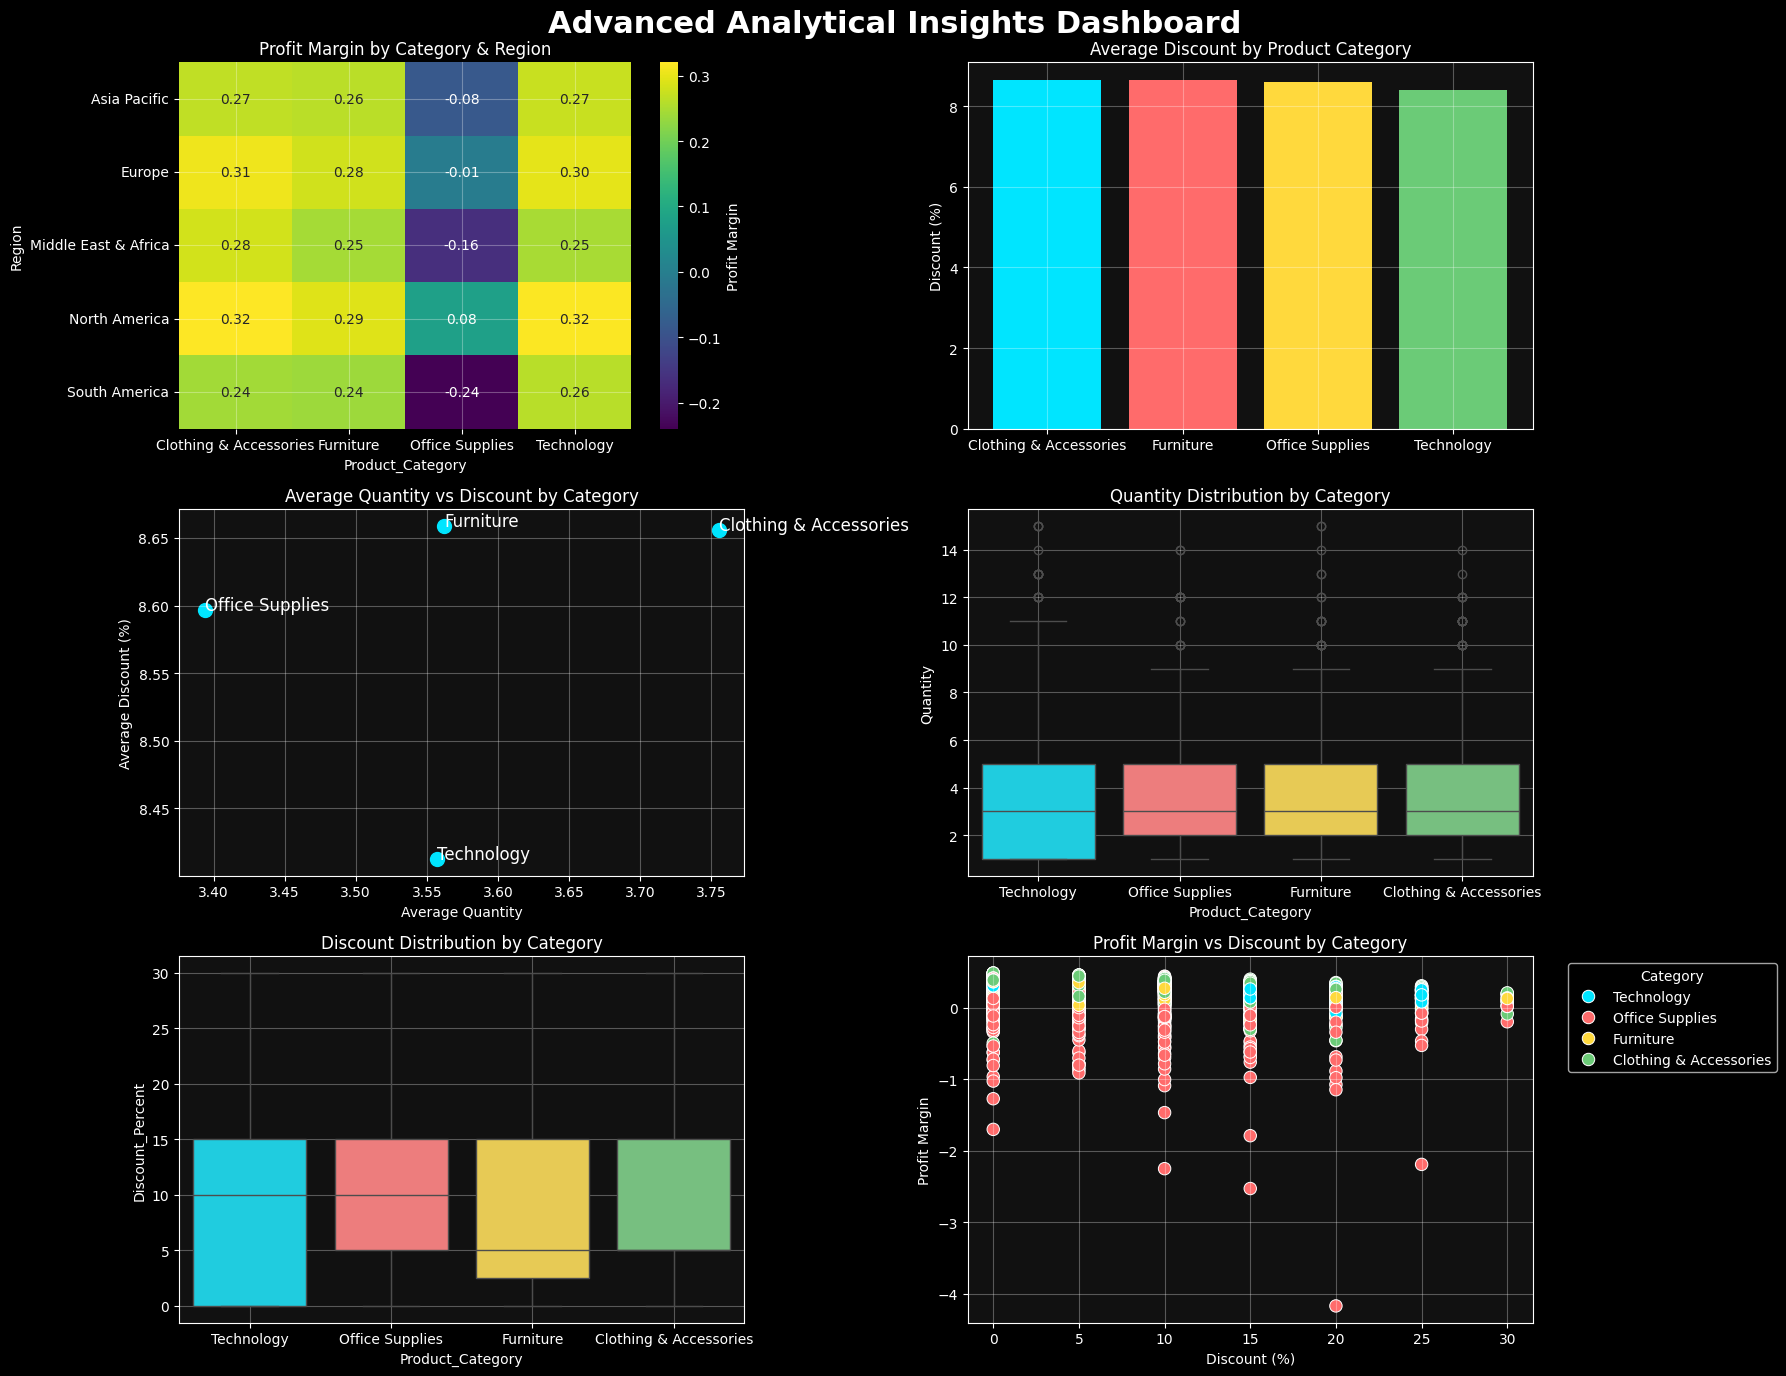

In [15]:
# ---------- Compute Metrics ----------
# Profit Margin by Category & Region
profit_cat_region = df.groupby(["Region","Product_Category"])["Profit_Margin"].mean().unstack()

# Average Discount by Product Category
discount_category = df.groupby("Product_Category")["Discount_Percent"].mean()

# Quantity vs Discount (Basket Size Analysis)
# We'll aggregate average quantity and discount per category
quantity_discount = df.groupby("Product_Category").agg({"Quantity":"mean","Discount_Percent":"mean"})

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(3,2, figsize=(18,14))
fig.suptitle("Advanced Analytical Insights Dashboard", fontsize=22, fontweight="bold")

# -------- Profit Margin by Category & Region (Heatmap) --------
ax = axes[0,0]
sns.heatmap(profit_cat_region, annot=True, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label":"Profit Margin"})
ax.set_title("Profit Margin by Category & Region")
ax.set_facecolor("#111111")
ax.title.set_color("white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.tick_params(colors="white")

# -------- Discount Sensitivity by Category (Bar) --------
ax = axes[0,1]
ax.bar(discount_category.index, discount_category.values, color=bright_colors[:len(discount_category)])
ax.set_title("Average Discount by Product Category")
ax.set_ylabel("Discount (%)")

# -------- Average Quantity vs Discount (Scatter) --------
ax = axes[1,0]
ax.scatter(quantity_discount["Quantity"], quantity_discount["Discount_Percent"], color=bright_colors[0], s=100)
for i, txt in enumerate(quantity_discount.index):
    ax.annotate(txt, (quantity_discount["Quantity"][i], quantity_discount["Discount_Percent"][i]), color="white", fontsize=12)
ax.set_title("Average Quantity vs Discount by Category")
ax.set_xlabel("Average Quantity")
ax.set_ylabel("Average Discount (%)")

# -------- Optional: Quantity Distribution by Category (Boxplot) --------
ax = axes[1,1]
sns.boxplot(x="Product_Category", y="Quantity", data=df, palette=bright_colors[:len(discount_category)], ax=ax)
ax.set_title("Quantity Distribution by Category")

# -------- Optional: Discount Distribution by Category (Boxplot) --------
ax = axes[2,0]
sns.boxplot(x="Product_Category", y="Discount_Percent", data=df, palette=bright_colors[:len(discount_category)], ax=ax)
ax.set_title("Discount Distribution by Category")

# -------- Optional: Scatter Profit vs Discount by Category --------
ax = axes[2,1]
sns.scatterplot(x="Discount_Percent", y="Profit_Margin", hue="Product_Category", palette=bright_colors[:len(discount_category)], data=df, s=80, ax=ax)
ax.set_title("Profit Margin vs Discount by Category")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Profit Margin")
ax.legend(title="Category", bbox_to_anchor=(1.05,1), loc="upper left")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **1️⃣1️⃣ Revenue Concentration Analysis (Pareto Principle)**

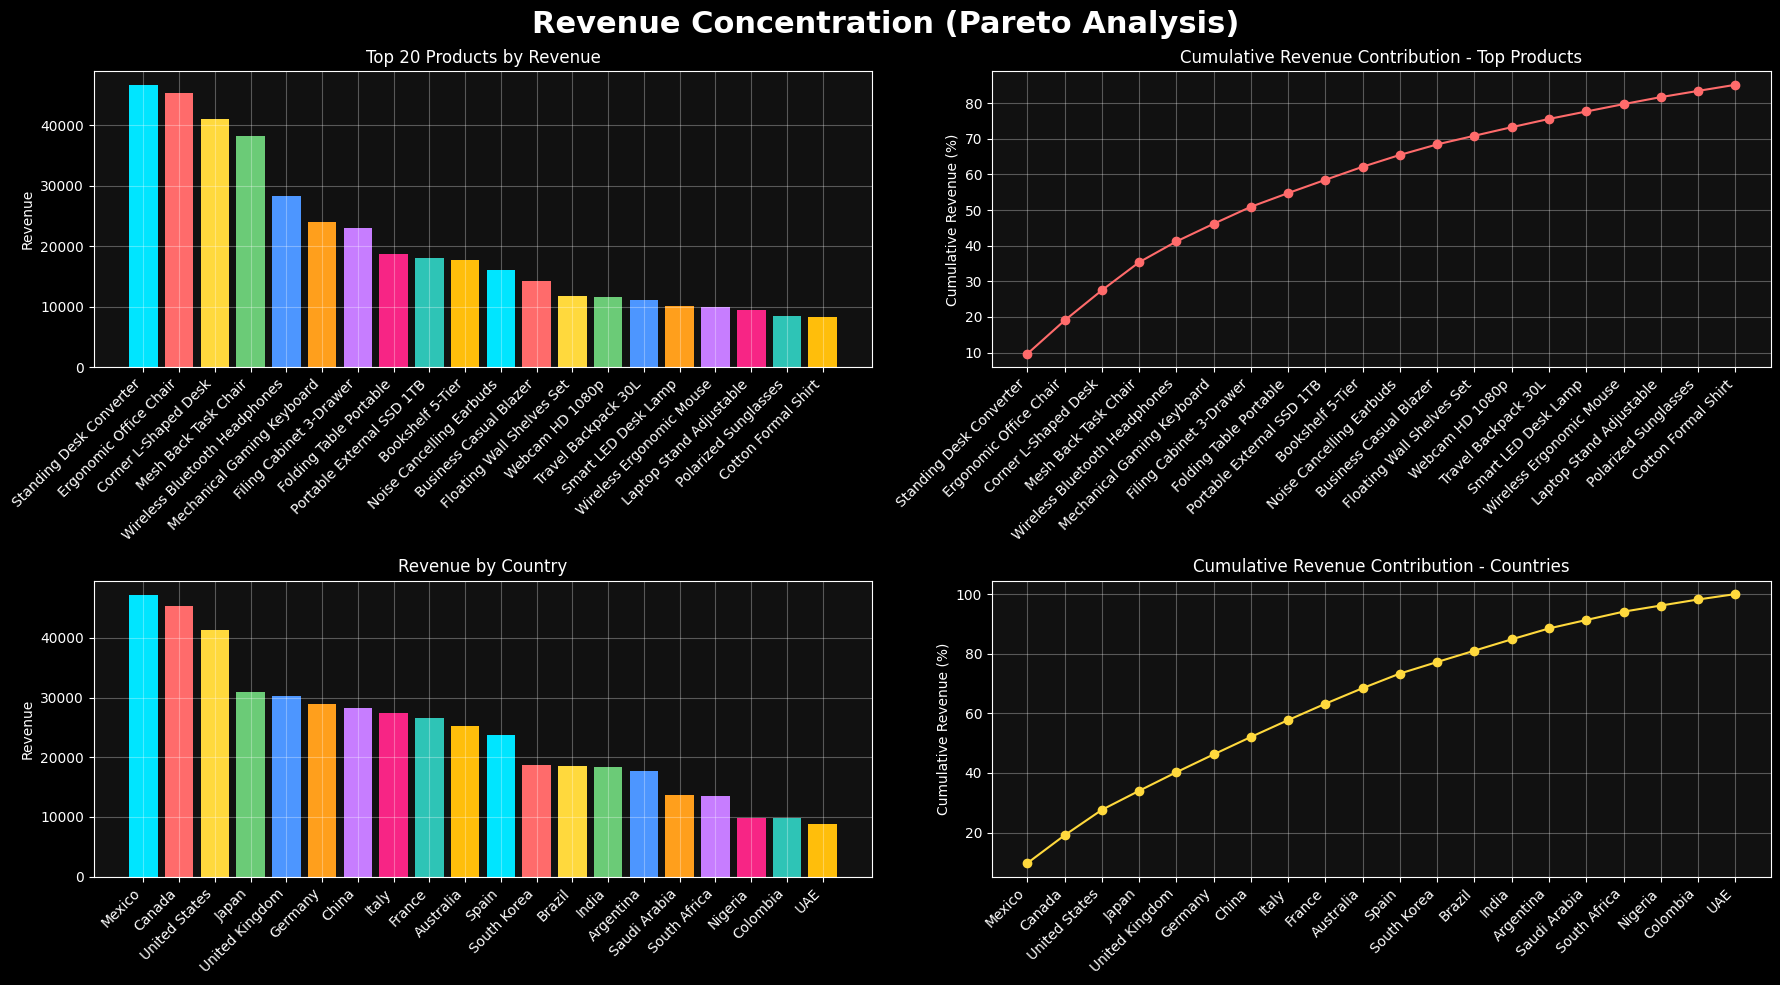

In [16]:
# ---------- Compute Metrics ----------
# Revenue contribution by Product
product_revenue = df.groupby("Product_Name")["Total_Sales"].sum().sort_values(ascending=False)
product_revenue_cum = product_revenue.cumsum() / product_revenue.sum() * 100  # cumulative %

# Revenue contribution by Country
country_revenue = df.groupby("Country")["Total_Sales"].sum().sort_values(ascending=False)
country_revenue_cum = country_revenue.cumsum() / country_revenue.sum() * 100  # cumulative %

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle("Revenue Concentration (Pareto Analysis)", fontsize=22, fontweight="bold")

# -------- Top Products Revenue (Bar) --------
ax = axes[0,0]
ax.bar(product_revenue.index[:20], product_revenue.values[:20], color=bright_colors[:20])
ax.set_title("Top 20 Products by Revenue")
ax.set_ylabel("Revenue")
ax.set_xticklabels(product_revenue.index[:20], rotation=45, ha="right")

# -------- Pareto Line for Products --------
ax2 = axes[0,1]
ax2.plot(product_revenue_cum.index[:20], product_revenue_cum.values[:20], color=bright_colors[1], marker="o")
ax2.set_title("Cumulative Revenue Contribution - Top Products")
ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_xticklabels(product_revenue_cum.index[:20], rotation=45, ha="right")

# -------- Top Countries Revenue (Bar) --------
ax = axes[1,0]
ax.bar(country_revenue.index, country_revenue.values, color=bright_colors[:len(country_revenue)])
ax.set_title("Revenue by Country")
ax.set_ylabel("Revenue")
ax.set_xticklabels(country_revenue.index, rotation=45, ha="right")

# -------- Pareto Line for Countries --------
ax2 = axes[1,1]
ax2.plot(country_revenue_cum.index, country_revenue_cum.values, color=bright_colors[2], marker="o")
ax2.set_title("Cumulative Revenue Contribution - Countries")
ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_xticklabels(country_revenue_cum.index, rotation=45, ha="right")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **1️⃣2️⃣ Profit Margin Distribution**

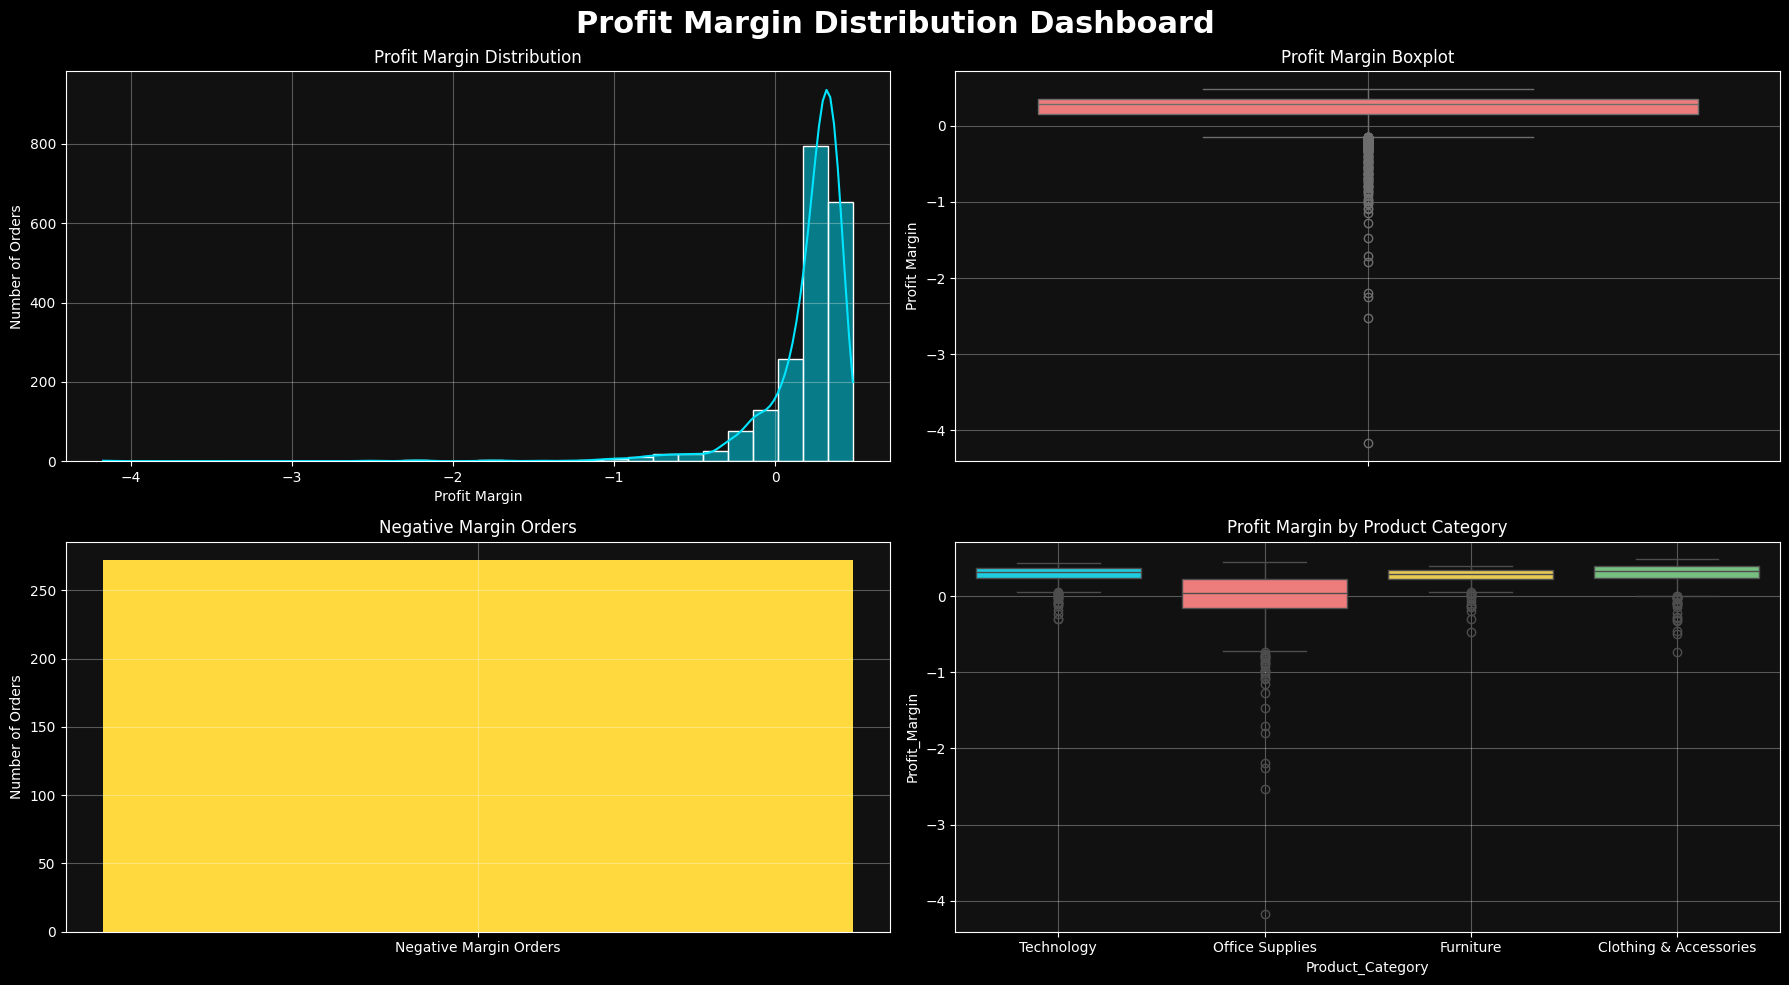

In [17]:
# ---------- Compute Metric ----------
df["Profit_Margin"] = df["Profit"] / df["Total_Sales"]

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle("Profit Margin Distribution Dashboard", fontsize=22, fontweight="bold")

# -------- Profit Margin Histogram --------
ax = axes[0,0]
sns.histplot(df["Profit_Margin"], bins=30, kde=True, color=bright_colors[0], ax=ax)
ax.set_title("Profit Margin Distribution")
ax.set_xlabel("Profit Margin")
ax.set_ylabel("Number of Orders")

# -------- Boxplot of Profit Margin --------
ax = axes[0,1]
sns.boxplot(y=df["Profit_Margin"], color=bright_colors[1], ax=ax)
ax.set_title("Profit Margin Boxplot")
ax.set_ylabel("Profit Margin")

# -------- Negative Margin Orders Count --------
ax = axes[1,0]
neg_margin_count = (df["Profit_Margin"] < 0).sum()
ax.bar(["Negative Margin Orders"], [neg_margin_count], color=bright_colors[2])
ax.set_title("Negative Margin Orders")
ax.set_ylabel("Number of Orders")

# -------- Profit Margin by Product Category (Boxplot) --------
ax = axes[1,1]
sns.boxplot(x="Product_Category", y="Profit_Margin", data=df, palette=bright_colors[:len(df["Product_Category"].unique())], ax=ax)
ax.set_title("Profit Margin by Product Category")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **1️⃣3️⃣ Discount Elasticity Analysis**

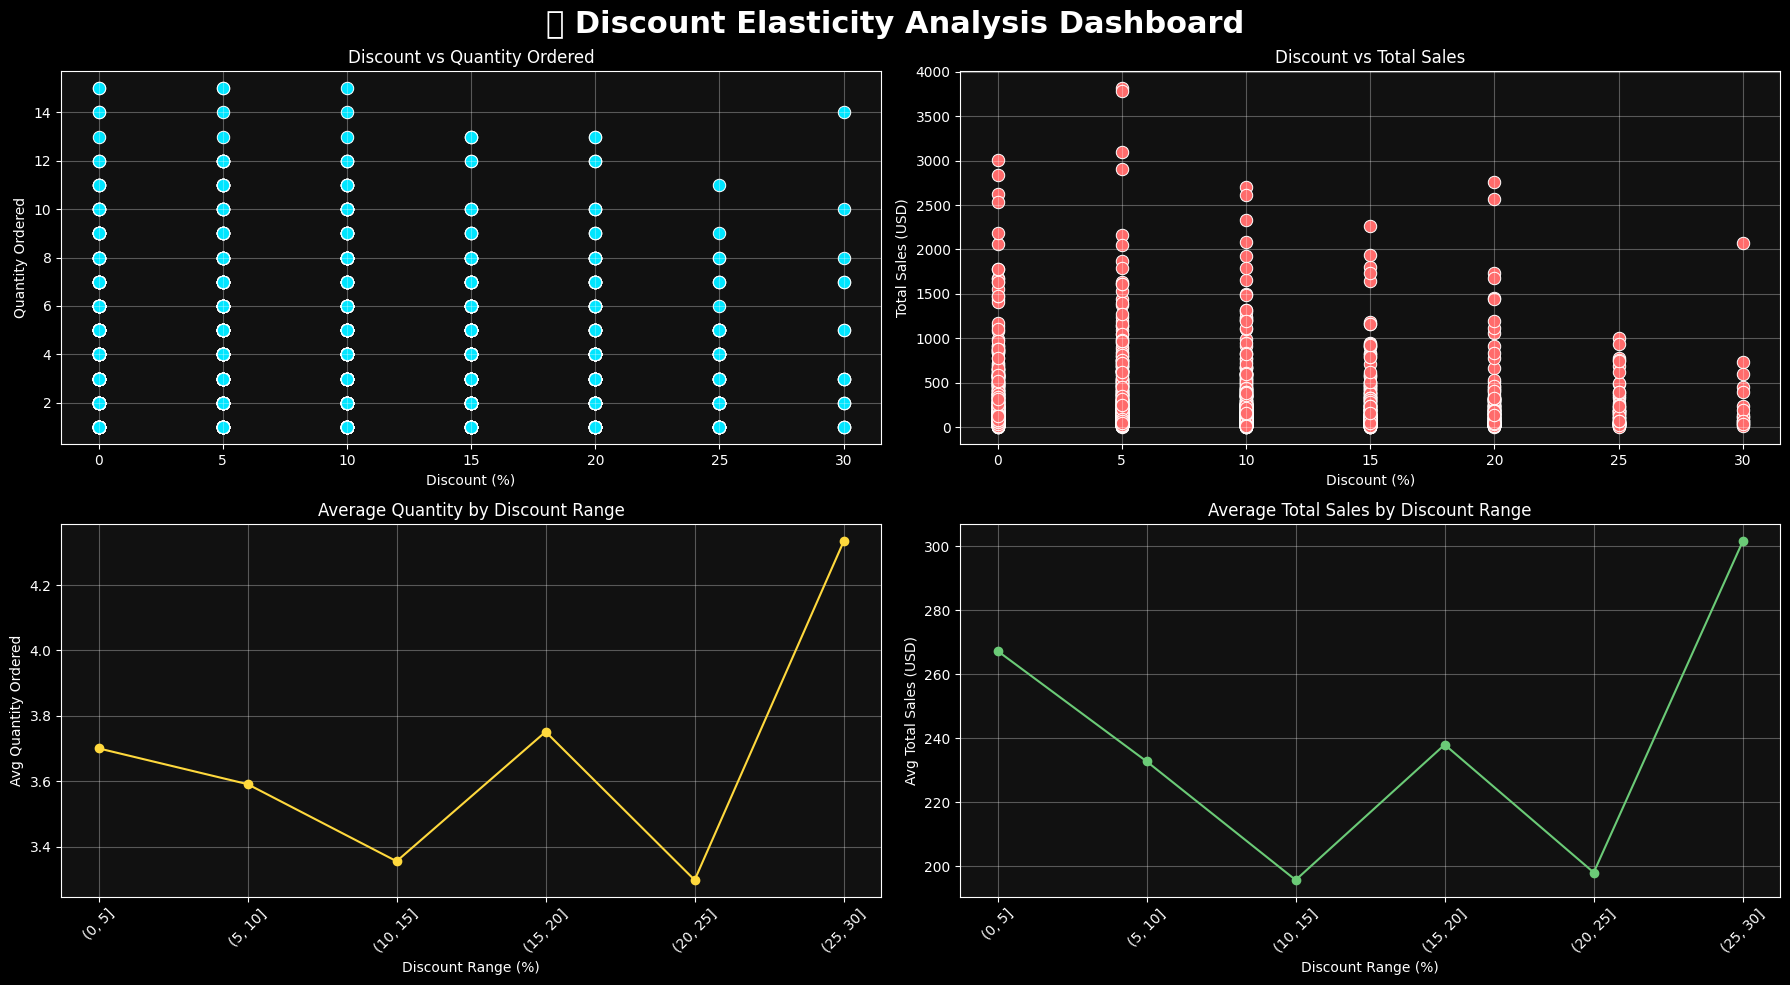

In [18]:
# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle("🎯 Discount Elasticity Analysis Dashboard", fontsize=22, fontweight="bold")

# -------- Scatter: Discount vs Quantity --------
ax = axes[0,0]
sns.scatterplot(x="Discount_Percent", y="Quantity", data=df, color=bright_colors[0], s=80, ax=ax)
ax.set_title("Discount vs Quantity Ordered")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Quantity Ordered")

# -------- Scatter: Discount vs Total Sales --------
ax = axes[0,1]
sns.scatterplot(x="Discount_Percent", y="Total_Sales", data=df, color=bright_colors[1], s=80, ax=ax)
ax.set_title("Discount vs Total Sales")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Total Sales (USD)")

# -------- Line Plot: Avg Quantity by Discount Range --------
ax = axes[1,0]
discount_bins = [0,5,10,15,20,25,30]
df["Discount_Bin"] = pd.cut(df["Discount_Percent"], bins=discount_bins)
avg_quantity_by_discount = df.groupby("Discount_Bin")["Quantity"].mean()
ax.plot(avg_quantity_by_discount.index.astype(str), avg_quantity_by_discount.values, color=bright_colors[2], marker="o")
ax.set_title("Average Quantity by Discount Range")
ax.set_xlabel("Discount Range (%)")
ax.set_ylabel("Avg Quantity Ordered")
ax.tick_params(axis="x", rotation=45)

# -------- Line Plot: Avg Total Sales by Discount Range --------
ax = axes[1,1]
avg_sales_by_discount = df.groupby("Discount_Bin")["Total_Sales"].mean()
ax.plot(avg_sales_by_discount.index.astype(str), avg_sales_by_discount.values, color=bright_colors[3], marker="o")
ax.set_title("Average Total Sales by Discount Range")
ax.set_xlabel("Discount Range (%)")
ax.set_ylabel("Avg Total Sales (USD)")
ax.tick_params(axis="x", rotation=45)

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **1️⃣4️⃣ Shipping Cost Efficiency**

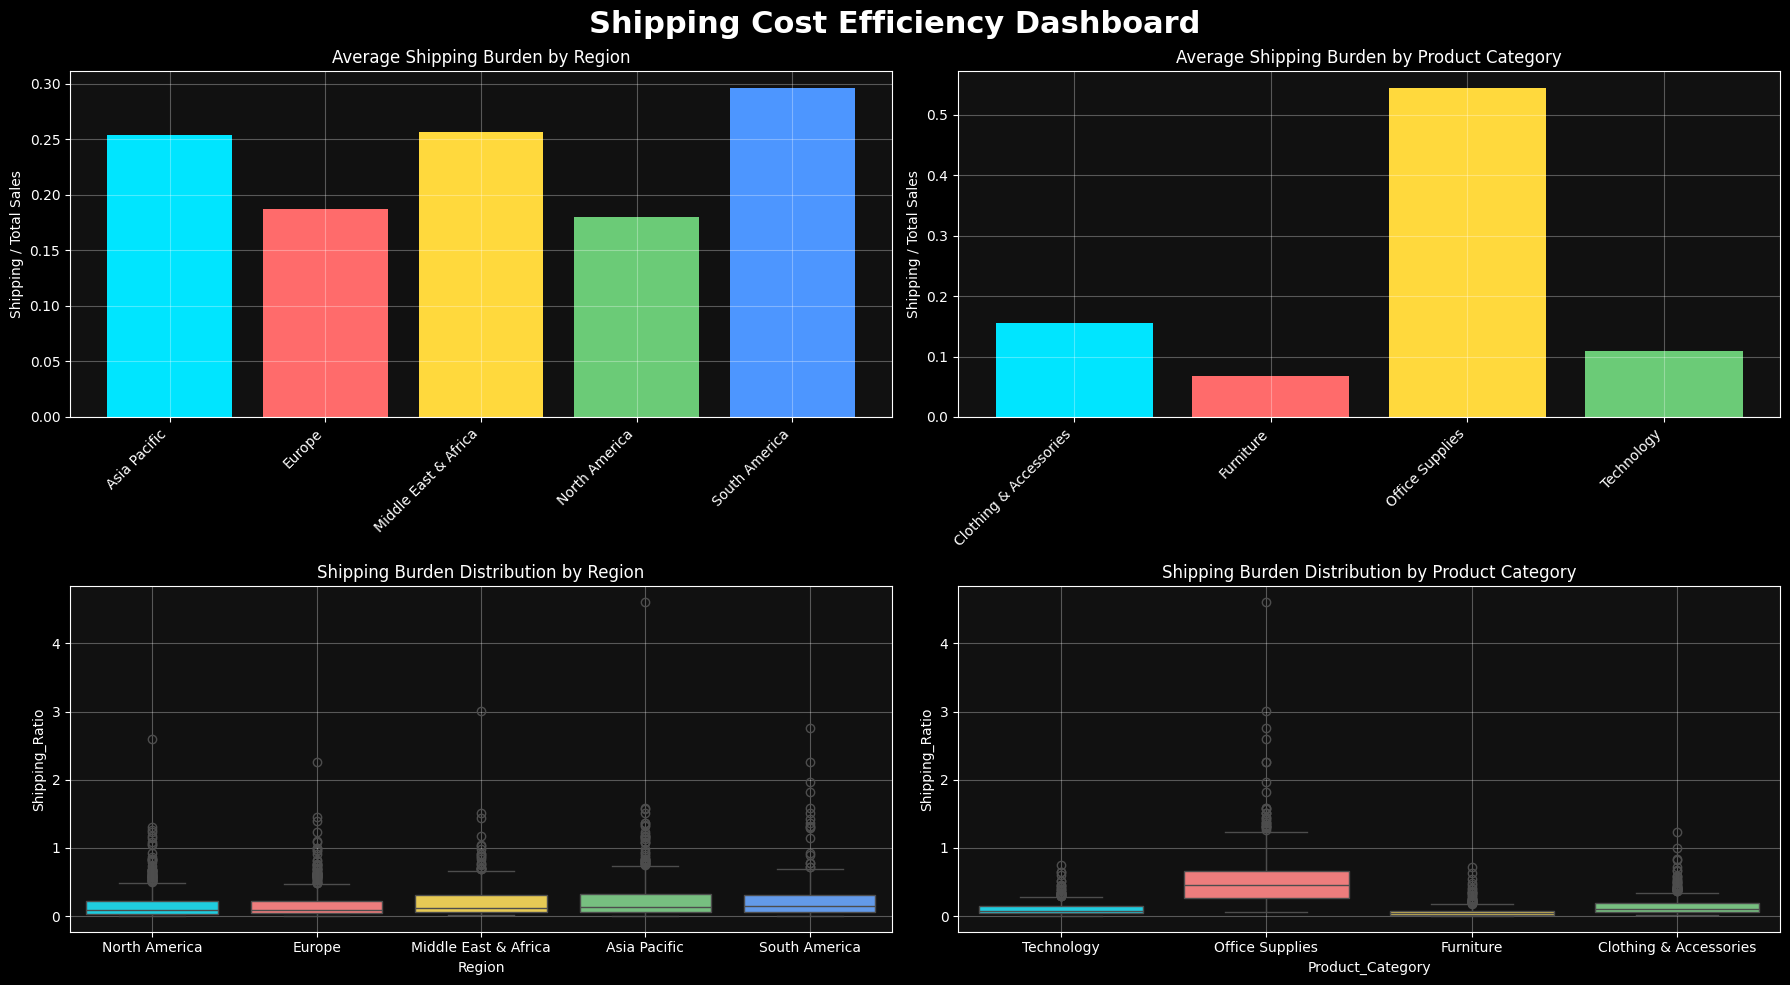

In [19]:
# ---------- Compute Metric ----------
df["Shipping_Ratio"] = df["Shipping_Cost"] / df["Total_Sales"]

# Aggregate by Region
shipping_region = df.groupby("Region")["Shipping_Ratio"].mean()

# Aggregate by Product Category
shipping_category = df.groupby("Product_Category")["Shipping_Ratio"].mean()

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle("Shipping Cost Efficiency Dashboard", fontsize=22, fontweight="bold")

# -------- Shipping Ratio by Region (Bar) --------
ax = axes[0,0]
ax.bar(shipping_region.index, shipping_region.values, color=bright_colors[:len(shipping_region)])
ax.set_title("Average Shipping Burden by Region")
ax.set_ylabel("Shipping / Total Sales")
ax.set_xticklabels(shipping_region.index, rotation=45, ha="right")

# -------- Shipping Ratio by Product Category (Bar) --------
ax = axes[0,1]
ax.bar(shipping_category.index, shipping_category.values, color=bright_colors[:len(shipping_category)])
ax.set_title("Average Shipping Burden by Product Category")
ax.set_ylabel("Shipping / Total Sales")
ax.set_xticklabels(shipping_category.index, rotation=45, ha="right")

# -------- Boxplot: Shipping Ratio by Region --------
ax = axes[1,0]
sns.boxplot(x="Region", y="Shipping_Ratio", data=df, palette=bright_colors[:len(shipping_region)], ax=ax)
ax.set_title("Shipping Burden Distribution by Region")

# -------- Boxplot: Shipping Ratio by Category --------
ax = axes[1,1]
sns.boxplot(x="Product_Category", y="Shipping_Ratio", data=df, palette=bright_colors[:len(shipping_category)], ax=ax)
ax.set_title("Shipping Burden Distribution by Product Category")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **1️⃣5️⃣ Profitability Efficiency Matrix**

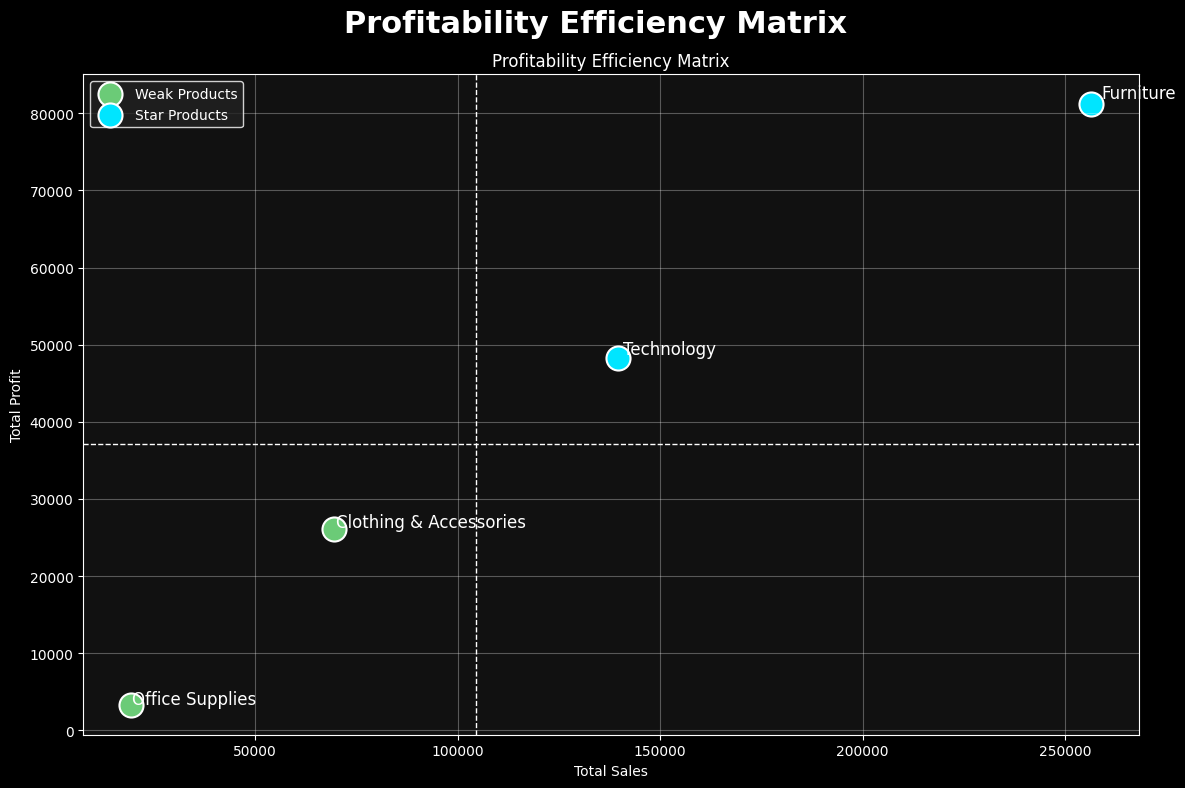

In [20]:
# ---------- Aggregate Sales & Profit by Product Category ----------
category_summary = df.groupby("Product_Category")[["Total_Sales","Profit"]].sum().reset_index()

# Determine thresholds (median-based)
sales_median = category_summary["Total_Sales"].median()
profit_median = category_summary["Profit"].median()

# Classify categories into quadrants
def classify(row):
    if row["Total_Sales"] >= sales_median and row["Profit"] >= profit_median:
        return "Star Products"
    elif row["Total_Sales"] >= sales_median and row["Profit"] < profit_median:
        return "Margin Risk"
    elif row["Total_Sales"] < sales_median and row["Profit"] >= profit_median:
        return "Niche Opportunities"
    else:
        return "Weak Products"

category_summary["Category_Type"] = category_summary.apply(classify, axis=1)

# ---------- Dashboard Layout ----------
fig, ax = plt.subplots(figsize=(12,8))
fig.suptitle("Profitability Efficiency Matrix", fontsize=22, fontweight="bold")

# Color mapping for quadrants
color_map = {
    "Star Products": bright_colors[0],
    "Margin Risk": bright_colors[1],
    "Niche Opportunities": bright_colors[2],
    "Weak Products": bright_colors[3]
}

# Scatter plot
for i, row in category_summary.iterrows():
    ax.scatter(
        row["Total_Sales"], 
        row["Profit"], 
        s=300, 
        color=color_map[row["Category_Type"]],
        label=row["Category_Type"],
        edgecolors="white",
        linewidth=1.5
    )
    ax.text(
        row["Total_Sales"]*1.01, 
        row["Profit"]*1.01, 
        row["Product_Category"], 
        color="white",
        fontsize=12
    )

# Draw median lines
ax.axvline(sales_median, color="white", linestyle="--", linewidth=1)
ax.axhline(profit_median, color="white", linestyle="--", linewidth=1)

ax.set_xlabel("Total Sales", color="white")
ax.set_ylabel("Total Profit", color="white")
ax.set_facecolor("#111111")
ax.grid(alpha=0.3)
ax.tick_params(colors="white")
ax.set_title("Profitability Efficiency Matrix", color="white")

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), facecolor="#222222", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.show()

# **1️⃣6️⃣ Customer Value Analysis**

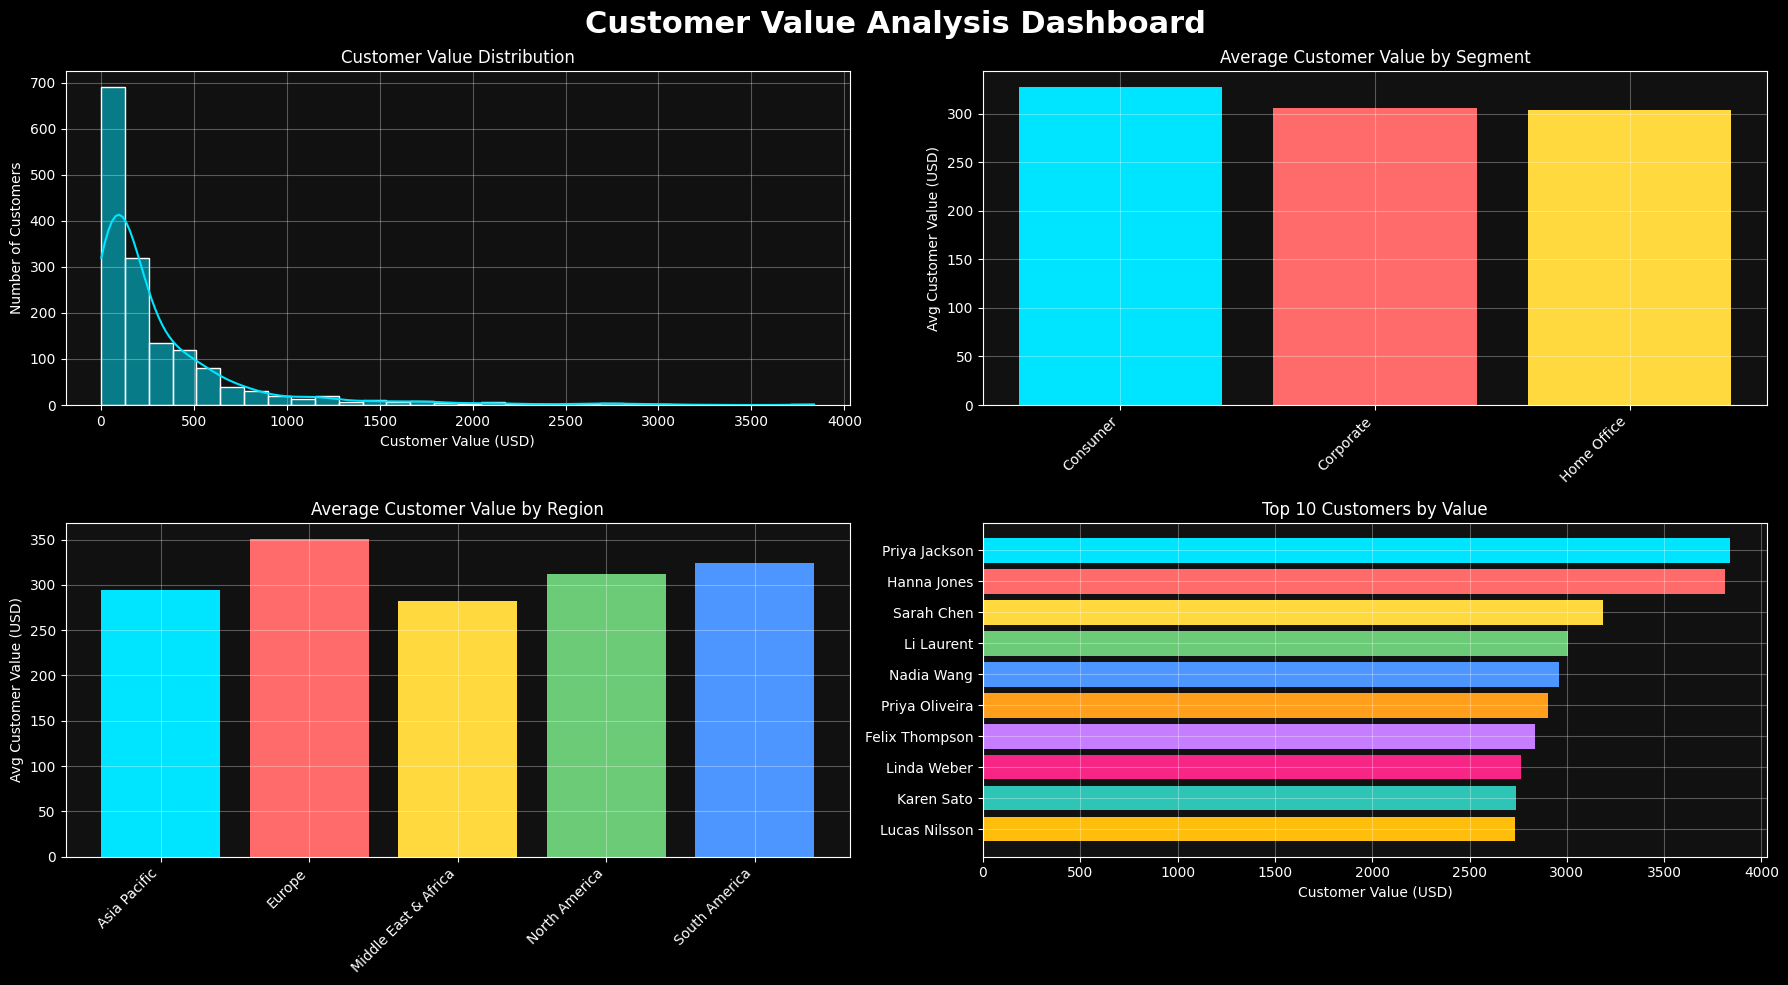

In [21]:
# ---------- Compute Customer Value ----------
customer_summary = df.groupby("Customer_Name")["Total_Sales"].sum().reset_index()
customer_summary = customer_summary.rename(columns={"Total_Sales": "Customer_Value"})

# Merge segment and region info
customer_info = df.groupby("Customer_Name")[["Customer_Segment","Region"]].first().reset_index()
customer_summary = customer_summary.merge(customer_info, on="Customer_Name", how="left")

# Aggregate by segment
segment_value = customer_summary.groupby("Customer_Segment")["Customer_Value"].mean()

# Aggregate by region
region_value = customer_summary.groupby("Region")["Customer_Value"].mean()

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle("Customer Value Analysis Dashboard", fontsize=22, fontweight="bold")

# -------- Customer Value Distribution --------
ax = axes[0,0]
sns.histplot(customer_summary["Customer_Value"], bins=30, kde=True, color=bright_colors[0], ax=ax)
ax.set_title("Customer Value Distribution")
ax.set_xlabel("Customer Value (USD)")
ax.set_ylabel("Number of Customers")

# -------- Average Customer Value by Segment --------
ax = axes[0,1]
ax.bar(segment_value.index, segment_value.values, color=bright_colors[:len(segment_value)])
ax.set_title("Average Customer Value by Segment")
ax.set_ylabel("Avg Customer Value (USD)")
ax.set_xticklabels(segment_value.index, rotation=45, ha="right")

# -------- Average Customer Value by Region --------
ax = axes[1,0]
ax.bar(region_value.index, region_value.values, color=bright_colors[:len(region_value)])
ax.set_title("Average Customer Value by Region")
ax.set_ylabel("Avg Customer Value (USD)")
ax.set_xticklabels(region_value.index, rotation=45, ha="right")

# -------- Top 10 Customers by Value --------
ax = axes[1,1]
top_customers = customer_summary.sort_values("Customer_Value", ascending=False).head(10)
ax.barh(top_customers["Customer_Name"], top_customers["Customer_Value"], color=bright_colors[:10])
ax.set_title("Top 10 Customers by Value")
ax.set_xlabel("Customer Value (USD)")
ax.invert_yaxis()

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **1️⃣7️⃣ Temporal Feature Engineering**

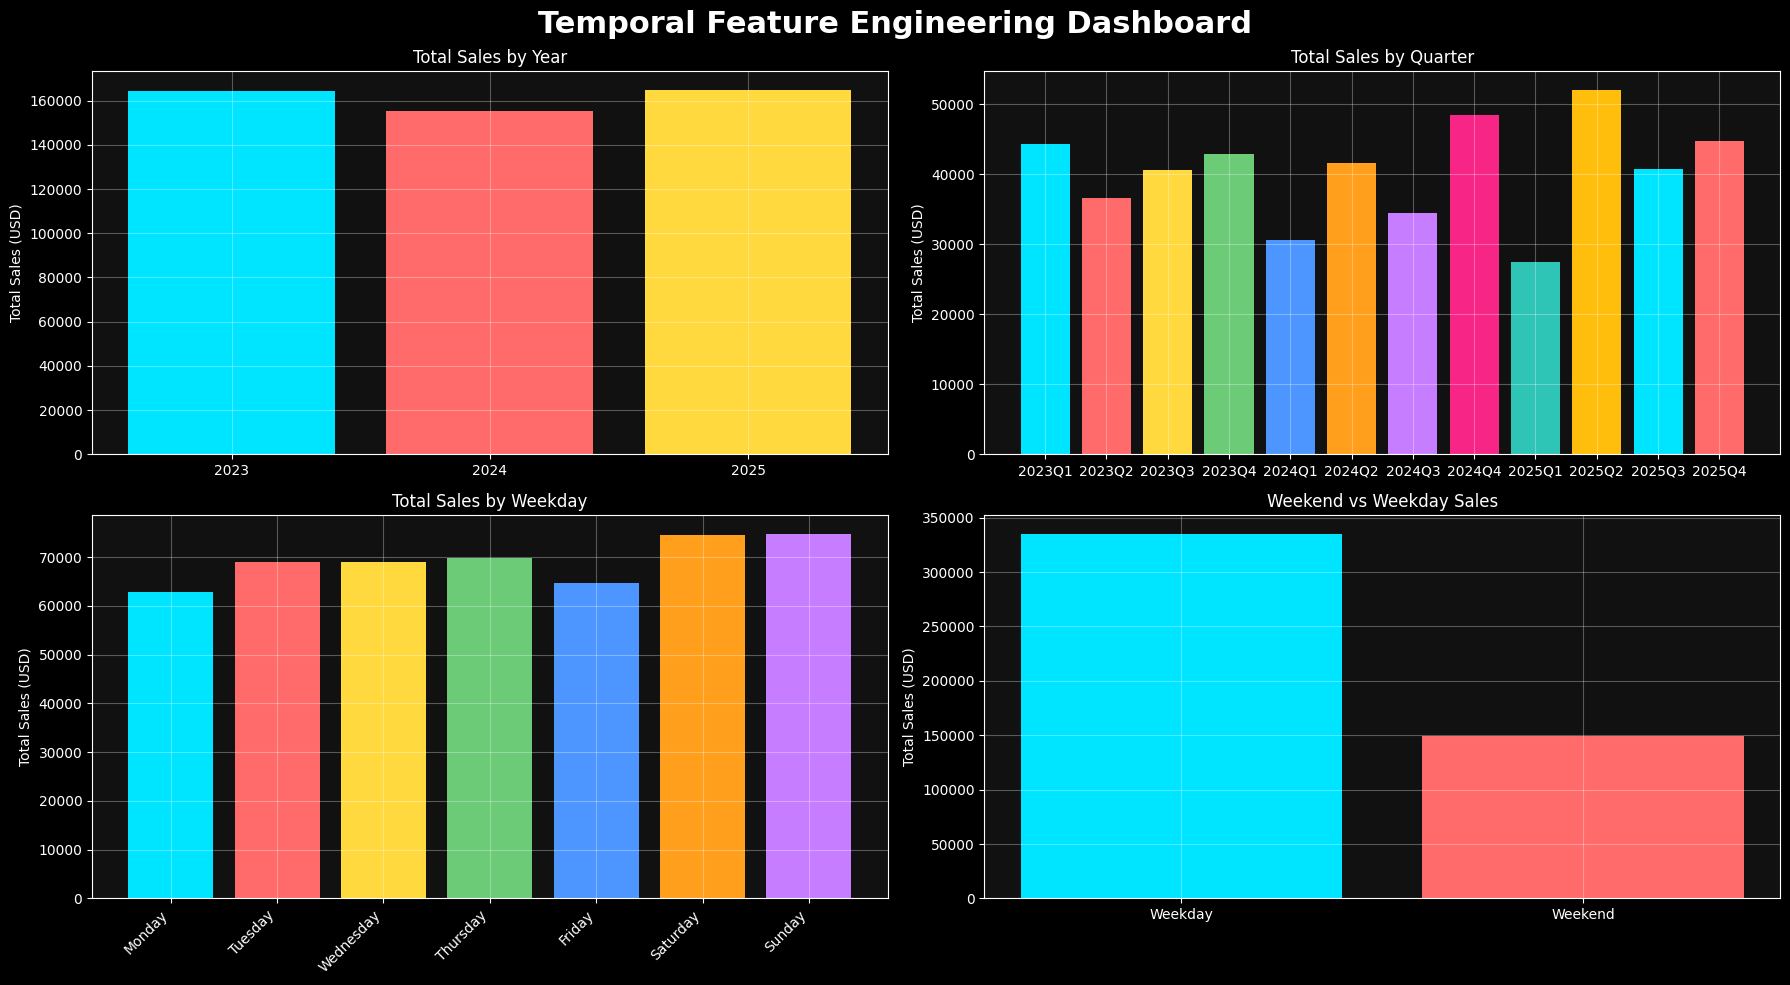

In [22]:
# ---------- Extract Temporal Features ----------
df["Day_of_Week"] = df["Order_Date"].dt.day_name()
df["Is_Weekend"] = df["Day_of_Week"].isin(["Saturday", "Sunday"])

# Aggregate Sales
yearly_sales = df.groupby("Year")["Total_Sales"].sum()
quarterly_sales = df.groupby("Quarter")["Total_Sales"].sum()
monthly_sales = df.groupby(["Year","Month"])["Total_Sales"].sum().reset_index()
weekday_sales = df.groupby("Day_of_Week")["Total_Sales"].sum()
weekend_sales = df.groupby("Is_Weekend")["Total_Sales"].sum()

# Order of weekdays
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_sales = weekday_sales.reindex(weekday_order)

# ---------- Dashboard Layout ----------
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle("Temporal Feature Engineering Dashboard", fontsize=22, fontweight="bold")

# -------- Yearly Sales --------
ax = axes[0,0]
ax.bar(yearly_sales.index.astype(str), yearly_sales.values, color=bright_colors[:len(yearly_sales)])
ax.set_title("Total Sales by Year")
ax.set_ylabel("Total Sales (USD)")

# -------- Quarterly Sales --------
ax = axes[0,1]
ax.bar(quarterly_sales.index.astype(str), quarterly_sales.values, color=bright_colors[:len(quarterly_sales)])
ax.set_title("Total Sales by Quarter")
ax.set_ylabel("Total Sales (USD)")

# -------- Sales by Weekday --------
ax = axes[1,0]
ax.bar(weekday_sales.index, weekday_sales.values, color=bright_colors[:7])
ax.set_title("Total Sales by Weekday")
ax.set_ylabel("Total Sales (USD)")
ax.set_xticklabels(weekday_sales.index, rotation=45, ha="right")

# -------- Weekend vs Weekday Sales --------
ax = axes[1,1]
ax.bar(["Weekday","Weekend"], weekend_sales.values, color=bright_colors[:2])
ax.set_title("Weekend vs Weekday Sales")
ax.set_ylabel("Total Sales (USD)")

# ---------- Styling ----------
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_facecolor("#111111")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# **Thank You!**

Thank you for exploring this **Global E-Commerce Sales & Customer Analysis** notebook.  

I hope the insights, visualizations, and dashboards presented here provide a clear understanding of **business performance, customer behavior, product profitability, and seasonal trends**.  

Your feedback and suggestions are highly appreciated as they help improve the depth and quality of analysis.  

**💡 Key Takeaway:**  
Data-driven insights are essential for **strategic decision-making**, **optimizing profitability**, and **enhancing customer satisfaction** in global e-commerce operations.  

**🚀 Happy Analyzing!**